<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 6. COMPARATIVA FINAL DE MODELOS PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Introducción y objetivos de la comparativa
        <br>
        2. Configuración técnica y variables globales
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. CARGA Y ARMONIZACIÓN DE PREDICCIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga de predicciones de test
        <br>
        4. Diagnóstico de codificación de etiquetas
        <br>
        5. Armonización a convención canónica (ALS=1, HC=0)
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. RECÁLCULO HOMOGÉNEO DE MÉTRICAS
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        6. Métricas recalculadas desde predicciones crudas
        <br>
        7. Validación cruzada con métricas pre-guardadas
        <br>
        8. Tabla resumen CV + Test
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. INFERENCIA ESTADÍSTICA
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        9. Intervalos de confianza bootstrap (95%)
        <br>
        10. Test de McNemar por pares de modelos
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. VISUALIZACIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        11. Curvas ROC superpuestas
        <br>
        12. Matrices de confusión
        <br>
        13. Barras de métricas con IC 95%
        <br>
        14. Distribución de probabilidades por clase
        <br>
        15. Mapa de errores por sujeto
        <br>
        16. Radar chart multimétrica
        <br>
        17. Variabilidad CV por fold
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. ANÁLISIS DE CONCORDANCIA Y ERRORES CLÍNICOS
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        18. Concordancia entre modelos
        <br>
        19. Voto mayoritario (ensemble de ensembles)
        <br>
        20. Análisis clínico de FN y FP
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        21. Tabla de decisión y ranking final
        <br>
        22. Conclusiones y recomendación del modelo
        <br>
        23. Exportación de resultados consolidados
        <br>
</span>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Introducción y objetivos de la comparativa</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook realiza la <b>comparativa homogénea y reproducible</b> de los 4 modelos entrenados en el proyecto para clasificación binaria ALS vs HC sobre el dataset VOC-ALS. Los 4 modelos se evalúan sobre el mismo hold-out de test (23 sujetos) y las métricas se recalculan íntegramente a partir de las predicciones crudas (<code>test_predictions.csv</code>) para garantizar consistencia.
<br><br>
<b>Modelos comparados:</b>
<br>
<ul>
<li><b>RF v1.0:</b>     Random Forest con 50 variables acústicas (baseline).</li>

<li><b>RF v2.0:</b>     Random Forest con 50 acústicas + Age + Sex (extendido).</li>

<li><b>BiLSTM v1.2:</b> BiLSTM bidireccional + attention sobre mel spectrograms (ensemble 5-fold).</li>

<li><b>AE v1.0:</b>     CNN2D Autoencoder + MLP clasificador sobre mel spectrograms (ensemble 5-fold).</li>
</ul>
    </span>
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Jerarquía de criterios de selección</strong>
    </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
<b>1. Recall ALS</b> (>=0.70 obligatorio), con el fin de minimizar falsos negativos en cribado diagnóstico.
<br>
<b>2. Balanced Accuracy</b> (>=0.60 deseable).
<br>
<b>3. AUC</b> (>=0.70 deseable).
<br>
<b>4. Recall HC / Specificity</b>, criterio de desempate clínico.
<br>
<b>5. Complejidad / Interpretabilidad</b>, criterio secundario de desempate.
    </span>
</div>

<div style="text-align:left;color:#6593BA;">
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;">
        <strong>Decisiones de diseño del experimento comparativo</strong>
    </span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook incorpora varias decisiones metodológicas orientadas a garantizar una comparación rigurosa y reproducible entre los cuatro modelos desarrollados a lo largo del proyecto. La primera y más fundamental es el <b>recálculo íntegro de métricas desde las predicciones crudas</b> (<code>test_predictions.csv</code>): en lugar de confiar en las métricas almacenadas en los JSON de cada notebook, todas las métricas se recalculan con las mismas funciones de scikit-learn, el mismo umbral de decisión (0.5) y la misma convención de etiquetas. Esto elimina cualquier posible inconsistencia derivada de diferencias en la implementación del cálculo entre notebooks.
<br><br>
La segunda decisión clave es la <b>armonización de etiquetas</b>. Los modelos RF utilizan la codificación del <code>LabelEncoder</code> de scikit-learn (ALS=0, HC=1 por orden alfabético), mientras que los modelos de Deep Learning construyen la etiqueta binaria manualmente como <code>(Category == "ALS").astype(int)</code>, resultando en ALS=1, HC=0. Antes de cualquier comparación, todas las predicciones se armonizan utilizando el split oficial (<code>subject_split.csv</code>) como fuente de verdad absoluta para las etiquetas <code>y_true</code>.
<br><br>
La tercera es la <b>evaluación exclusiva sobre el hold-out de test</b> (23 sujetos, 15% del dataset). Este conjunto no ha participado en ninguna decisión de modelado de ninguno de los cuatro modelos y se evalúa una única vez al final de cada pipeline. La cuarta decisión es la inclusión de <b>inferencia estadística explícita</b>: con n=23, las métricas puntuales son inestables (1 sujeto ≈ 4 puntos porcentuales), por lo que se cuantifica la incertidumbre mediante bootstrap estratificado (10.000 réplicas) y se incluyen tests de McNemar exactos para comparaciones por pares. Finalmente, el ranking se construye mediante un <b>score compuesto ponderado</b> (Recall ALS 40%, BalAcc 25%, AUC 25%, Recall HC 10%) que refleja la prioridad clínica del cribado diagnóstico.
    </span>
</div>


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se carga la configuración centralizada desde <code>config.yaml</code> y se definen las rutas a los artefactos de resultados, las predicciones y el split oficial. Todas las dependencias se importan aquí.
    </span>
</div>

In [18]:
# CONFIGURACIÓN DEL ENTORNO
import json
import warnings
from pathlib import Path
from collections import OrderedDict
from itertools import combinations

import numpy as np
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    balanced_accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

SEED = 42
print("Librerías importadas correctamente")
print(f"  NumPy:        {np.__version__}")
print(f"  Pandas:       {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")

Librerías importadas correctamente
  NumPy:        2.2.6
  Pandas:       2.3.3
  Scikit-learn: 1.7.2


In [19]:
# CONFIG + RUTAS (parametrizadas vía config.yaml)
def load_config() -> dict:
    env_path = os.environ.get("TFG_CONFIG")

    # 1) Si TFG_CONFIG está definido y existe
    if env_path:
        env_cfg = Path(env_path)
        if env_cfg.exists():
            cfg_path = env_cfg
        else:
            raise FileNotFoundError(f"TFG_CONFIG apunta a un archivo que no existe: {env_cfg}")
    else:
        # 2) Buscar config.yaml subiendo desde CWD
        cfg_path = None
        for parent in [Path.cwd()] + list(Path.cwd().parents):
            candidate = parent / "config.yaml"
            if candidate.exists():
                cfg_path = candidate
                break

    if cfg_path is None:
        raise FileNotFoundError(
            "config.yaml no encontrado. Ejecuta el notebook desde el repo o define TFG_CONFIG."
        )

    with open(cfg_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f) or {}

    root = cfg_path.parent.resolve()

    # Normalizar paths relativos (absolutos)
    paths = config.get("paths", {}) or {}
    norm_paths = {}
    for key, val in paths.items():
        if key == "project_root":
            continue
        if val is None:
            continue
        norm_paths[key] = str((root / str(val)).resolve())
    norm_paths["project_root"] = str(root)

    config["paths"] = norm_paths
    return config


# Carga de CONFIG con fallback a ruta conocida del proyecto
try:
    CONFIG = load_config()
    PROJECT_ROOT = Path(CONFIG["paths"]["project_root"])
    RESULTS_DIR = Path(CONFIG["paths"]["results"])
    SPLITS_DIR = Path(CONFIG["paths"]["splits"])
    SEED = int(CONFIG.get("seed", 42))
    print(f"config.yaml cargado desde: {PROJECT_ROOT}")
except FileNotFoundError as e:
    print(f"[WARN] {e}")

    PROJECT_ROOT = Path(r"C:\Users\Laura\OneDrive\TFG").resolve()
    RESULTS_DIR = PROJECT_ROOT / "results"
    SPLITS_DIR = PROJECT_ROOT / "artifacts" / "splits"
    SEED = 42

    print(f"[FALLBACK] Usando PROJECT_ROOT={PROJECT_ROOT}")

# Registro de modelos 
MODEL_REGISTRY = OrderedDict({
    "RF v1.0": {
        "dir": "02_rf_v1_0",
        "short_name": "RF v1.0",
        "type": "ML clasico",
        "features": "50 acusticas",
        "color": "#2196F3",
        "marker": "o",
        "interpretable": True,
    },
    "RF v2.0": {
        "dir": "02_rf_v2_0",
        "short_name": "RF v2.0",
        "type": "ML clasico",
        "features": "50 acusticas + Age + Sex",
        "color": "#4CAF50",
        "marker": "s",
        "interpretable": True,
    },
    "BiLSTM v1.2": {
        "dir": "04_bilstm_v1_2",
        "short_name": "BiLSTM v1.2",
        "type": "Deep Learning",
        "features": "Mel spectrograms",
        "color": "#FF9800",
        "marker": "D",
        "interpretable": False,
    },
    "AE v1.0": {
        "dir": "05_autoencoder_v1_0",
        "short_name": "AE v1.0",
        "type": "Deep Learning",
        "features": "Mel spectrograms",
        "color": "#E91E63",
        "marker": "^",
        "interpretable": False,
    },
})

print("\nRESULTS_DIR:", RESULTS_DIR.resolve())
print("SPLITS_DIR :", SPLITS_DIR.resolve())
print("SEED      :", SEED)

# Comprobación de carpetas 
for name, info in MODEL_REGISTRY.items():
    model_dir = RESULTS_DIR / info["dir"]
    sym = "OK" if model_dir.exists() else "MISSING"
    print(f"  [{sym}] {name}: {model_dir}")

config.yaml cargado desde: C:\Users\Laura\OneDrive\TFG

RESULTS_DIR: C:\Users\Laura\OneDrive\TFG\results
SPLITS_DIR : C:\Users\Laura\OneDrive\TFG\artifacts\splits
SEED      : 42
  [OK] RF v1.0: C:\Users\Laura\OneDrive\TFG\results\02_rf_v1_0
  [OK] RF v2.0: C:\Users\Laura\OneDrive\TFG\results\02_rf_v2_0
  [OK] BiLSTM v1.2: C:\Users\Laura\OneDrive\TFG\results\04_bilstm_v1_2
  [OK] AE v1.0: C:\Users\Laura\OneDrive\TFG\results\05_autoencoder_v1_0


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. CARGA Y ARMONIZACIÓN DE PREDICCIONES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque carga las predicciones crudas de los 4 modelos sobre el test set, diagnostica la codificación de etiquetas de cada uno y armoniza todas las predicciones a la convención canónica del proyecto (ALS=1, HC=0).
    </span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga de predicciones de test</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se cargan los ficheros <code>test_predictions.csv</code> de cada modelo (23 sujetos).
    </span>
</div>

In [20]:
# Carga de predicciones crudas
raw_predictions = {}
for name, info in MODEL_REGISTRY.items():
    pred_path = RESULTS_DIR / info["dir"] / "test_predictions.csv"
    if pred_path.exists():
        df = pd.read_csv(pred_path)
        raw_predictions[name] = df
        print(f"  [OK] {name}: {len(df)} sujetos cargados")
    else:
        print(f"  [MISSING] {name}: NO encontrado en {pred_path}")
print(f"\nModelos con predicciones: {len(raw_predictions)}/{len(MODEL_REGISTRY)}")

  [OK] RF v1.0: 23 sujetos cargados
  [OK] RF v2.0: 23 sujetos cargados
  [OK] BiLSTM v1.2: 23 sujetos cargados
  [OK] AE v1.0: 23 sujetos cargados

Modelos con predicciones: 4/4


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Diagnóstico de codificación de etiquetas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Los modelos RF codifican <b>ALS=0, HC=1</b>; los DL usan <b>ALS=1, HC=0</b>. La columna <code>prob_ALS</code> del RF ya representa P(ALS); solo se invierte <code>y_true</code>.
    </span>
</div>

In [21]:
# DIAGNÓSTICO DE CODIFICACIÓN DE ETIQUETAS
print("=" * 70)
print("DIAGNÓSTICO DE CODIFICACIÓN DE ETIQUETAS")
print("=" * 70)

split_path = SPLITS_DIR / "subject_split.csv"
if split_path.exists():
    split_df = pd.read_csv(split_path)
    test_split = split_df[split_df["Split"] == "Test"][["ID", "Category"]].copy()
    test_split["y_true_canonical"] = (test_split["Category"] == "ALS").astype(int)
    print(f"\n[OK] Split oficial: {len(test_split)} sujetos en test")
    print(f"  ALS: {(test_split['y_true_canonical'] == 1).sum()}, HC: {(test_split['y_true_canonical'] == 0).sum()}")
    USE_SPLIT_GT = True
else:
    print("\n[WARN] subject_split.csv no encontrado")
    USE_SPLIT_GT = False

print("\n" + "-" * 70)
for name, df in raw_predictions.items():
    ct_labels = df[df["ID"].str.startswith("CT")]["y_true"].unique()
    pz_labels = df[df["ID"].str.startswith("PZ")]["y_true"].unique()
    inverted = (1 in ct_labels and len(ct_labels) == 1 and 0 in pz_labels and len(pz_labels) == 1)
    print(f"\n  {name}: CT->{sorted(ct_labels)}, PZ->{sorted(pz_labels)}", end="")
    if inverted:
        print(" [ALS=0/HC=1, se armonizara]")
    else:
        print(" [OK]")

DIAGNÓSTICO DE CODIFICACIÓN DE ETIQUETAS

[OK] Split oficial: 23 sujetos en test
  ALS: 16, HC: 7

----------------------------------------------------------------------

  RF v1.0: CT->[np.int64(1)], PZ->[np.int64(0)] [ALS=0/HC=1, se armonizara]

  RF v2.0: CT->[np.int64(1)], PZ->[np.int64(0)] [ALS=0/HC=1, se armonizara]

  BiLSTM v1.2: CT->[np.int64(0)], PZ->[np.int64(1)] [OK]

  AE v1.0: CT->[np.int64(0)], PZ->[np.int64(1)] [OK]


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Armonización a convención canónica (ALS=1, HC=0)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La armonización se ha realizado correctamente. Los cuatro modelos reportan ahora exactamente 16 sujetos ALS y 7 HC en el test set, y la verificación de consistencia inter-modelo confirma que las etiquetas <code>y_true</code> son idénticas entre todos ellos. Los modelos RF han sido detectados automáticamente con codificación ALS=0/HC=1 y sus etiquetas <code>y_true</code> se han invertido (0→1 para ALS, 1→0 para HC), mientras que <code>prob_ALS</code> se ha mantenido intacta, puesto que ya representaba la probabilidad de la clase ALS independientemente de la codificación de las etiquetas. Las predicciones binarias <code>y_pred</code> se han recalculado desde <code>prob_ALS</code> con umbral 0.5 en la convención canónica. Para los modelos DL, que ya usaban ALS=1/HC=0, no ha sido necesaria ninguna transformación.
    </span>
</div>

In [22]:
# ARMONIZACIÓN DE ETIQUETAS 
def harmonize_predictions(raw_preds, split_gt=None):
    harmonized = {}

    if not raw_preds:
        raise ValueError(
            "raw_predictions está vacío. Revisa la celda de carga de CSVs "
            "(ruta/patrón) antes de armonizar."
        )

    for name, df in raw_preds.items():
        if df is None or df.empty:
            print(f"  [WARN] {name}: DataFrame vacío, se omite")
            continue

        required = {"ID", "y_true", "y_pred", "prob_ALS"}
        missing = required - set(df.columns)
        if missing:
            print(f"  [WARN] {name}: faltan columnas {sorted(missing)}, se omite")
            continue

        df_h = df.copy()
        df_h["ID"] = df_h["ID"].astype(str)
        df_h["y_true"] = pd.to_numeric(df_h["y_true"], errors="coerce")
        df_h["prob_ALS"] = pd.to_numeric(df_h["prob_ALS"], errors="coerce")
        df_h = df_h.dropna(subset=["ID", "y_true", "prob_ALS"]).copy()
        df_h["y_true"] = df_h["y_true"].astype(int)

        ct_mask = df_h["ID"].str.startswith("CT")
        pz_mask = df_h["ID"].str.startswith("PZ")
        ct_all_1 = ct_mask.any() and (df_h.loc[ct_mask, "y_true"] == 1).all()
        pz_all_0 = pz_mask.any() and (df_h.loc[pz_mask, "y_true"] == 0).all()
        is_als0_hc1 = ct_all_1 and pz_all_0

        if is_als0_hc1:
            print(f"  {name}: ALS=0/HC=1 detectada, armonizando...")
            df_h["y_true"] = 1 - df_h["y_true"]
            # prob_ALS ya es P(ALS) -- NO invertir
            df_h["y_pred"] = (df_h["prob_ALS"] >= 0.5).astype(int)
        else:
            # Recalcular y_pred para homogeneidad
            df_h["y_pred"] = (df_h["prob_ALS"] >= 0.5).astype(int)

        if split_gt is not None:
            gt_map = dict(zip(split_gt["ID"].astype(str), split_gt["y_true_canonical"]))
            df_h["y_true_from_split"] = df_h["ID"].map(gt_map)

            missing_gt = df_h["y_true_from_split"].isna().sum()
            if missing_gt > 0:
                print(f"  [WARN] {name}: {missing_gt} IDs sin GT en split, se mantienen y_true actuales")
                mask = df_h["y_true_from_split"].notna()
                df_h.loc[mask, "y_true"] = df_h.loc[mask, "y_true_from_split"].astype(int)
            else:
                df_h["y_true"] = df_h["y_true_from_split"].astype(int)

            df_h = df_h.drop(columns=["y_true_from_split"])

        harmonized[name] = df_h
        n_als = int((df_h["y_true"] == 1).sum())
        n_hc = int((df_h["y_true"] == 0).sum())
        print(f"  [OK] {name}: ALS={n_als}, HC={n_hc}, n={len(df_h)}")

    if not harmonized:
        raise ValueError(
            "Tras validar/armonizar, no quedó ningún modelo. "
            "Revisa columnas/rutas de los CSV cargados."
        )

    return harmonized

print("Armonizando predicciones...\n")
predictions = harmonize_predictions(raw_predictions, test_split if USE_SPLIT_GT else None)

# Verificar consistencia inter-modelo (robusto)
print("\n" + "=" * 70)
if not predictions:
    raise ValueError("predictions quedó vacío tras armonización.")

ref_name = next(iter(predictions))
ref_gt = predictions[ref_name].set_index("ID")["y_true"]

all_ok = True
for name, df in predictions.items():
    model_gt = df.set_index("ID")["y_true"]
    common = ref_gt.index.intersection(model_gt.index)

    if len(common) == 0:
        all_ok = False
        print(f"  [WARN] {name} vs {ref_name}: sin IDs comunes")
        continue

    mismatches = int((ref_gt.loc[common] != model_gt.loc[common]).sum())
    if mismatches > 0:
        all_ok = False
        print(f"  [WARN] {name} vs {ref_name}: {mismatches} discrepantes (sobre {len(common)} IDs)")

if all_ok:
    print("  [OK] Etiquetas consistentes entre todos los modelos")

Armonizando predicciones...

  RF v1.0: ALS=0/HC=1 detectada, armonizando...
  [OK] RF v1.0: ALS=16, HC=7, n=23
  RF v2.0: ALS=0/HC=1 detectada, armonizando...
  [OK] RF v2.0: ALS=16, HC=7, n=23
  [OK] BiLSTM v1.2: ALS=16, HC=7, n=23
  [OK] AE v1.0: ALS=16, HC=7, n=23

  [OK] Etiquetas consistentes entre todos los modelos


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. RECÁLCULO HOMOGÉNEO DE MÉTRICAS</span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Métricas recalculadas desde predicciones crudas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La tabla de métricas recalculadas sobre el test set revela diferencias sustanciales entre los cuatro modelos. El <b>BiLSTM v1.2</b> obtiene el mejor perfil global con una Balanced Accuracy de 0.7634, un Recall ALS de 0.8125, un Recall HC de 0.7143 y un AUC de 0.8571. Es el único modelo que supera simultáneamente los tres umbrales clínicos deseables (Recall ALS ≥ 0.70, BalAcc ≥ 0.60, AUC ≥ 0.70) y, crucialmente, también supera el umbral en Recall HC. Su distribución de errores es la más equilibrada del conjunto: solo 3 FN y 2 FP, sin sacrificar la detección de una clase en favor de la otra. Con 13 de 16 ALS detectados y 5 de 7 HC correctos, el BiLSTM demuestra capacidad discriminativa genuina en ambas direcciones.
<br><br>
El <b>AE v1.0</b> presenta un Recall ALS idéntico al BiLSTM (0.8125), detectando también 13 de 16 sujetos ALS. Sin embargo, este resultado se obtiene a costa de una especificidad muy baja: su Recall HC es de solo 0.2857, lo que significa que únicamente 2 de los 7 controles sanos se clasifican correctamente, generando 5 falsos positivos. La Balanced Accuracy resultante (0.5491) está apenas por encima del azar, y el AUC (0.6071) confirma una capacidad discriminativa limitada. El contraste con el BiLSTM es revelador: ambos detectan el mismo número de ALS, pero el BiLSTM lo consigue manteniendo un Recall HC de 0.7143 frente al 0.2857 del AE, una diferencia de 43 puntos porcentuales en especificidad que refleja la superioridad del BiLSTM en discriminación global.
<br><br>
Los modelos <b>RF v1.0 y v2.0</b> producen métricas idénticas en test (BalAcc 0.5982, Recall ALS 0.6250, AUC 0.6071), confirmando empíricamente que las variables demográficas (Age, Sex) no aportan capacidad discriminativa incremental cuando las 50 variables acústicas ya están presentes.
    </span>
</div>

In [23]:
# CÁLCULO HOMOGÉNEO DE MÉTRICAS EN TEST
def compute_all_metrics(y_true, prob_als, threshold=0.5):
    # Homogeneizar predicción binaria desde probabilidad
    y_true = pd.Series(y_true).astype(int).values
    prob_als = pd.Series(prob_als).astype(float).values
    y_pred = (prob_als >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # 0=HC, 1=ALS
    tn, fp, fn, tp = cm.ravel()

    return {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "N_ALS": int((y_true == 1).sum()), "N_HC": int((y_true == 0).sum()),
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall ALS (Sensitivity)": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall HC (Specificity)": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Precision ALS (PPV)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Precision HC (NPV)": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F1 ALS": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 HC": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "AUC": roc_auc_score(y_true, prob_als),
    }

METRIC_KEY_MAP = {
    "Balanced Accuracy": "Balanced Accuracy",
    "Recall ALS": "Recall ALS (Sensitivity)",
    "Recall HC": "Recall HC (Specificity)",
    "AUC": "AUC",
    "F1 ALS": "F1 ALS",
}

# Safety check
if "predictions" not in globals() or not predictions:
    raise ValueError("`predictions` está vacío.")

test_metrics = {}
for name, df in predictions.items():
    required = {"y_true", "prob_ALS"}
    missing = required - set(df.columns)
    if missing:
        print(f"[WARN] {name}: faltan columnas {missing}, se omite")
        continue
    test_metrics[name] = compute_all_metrics(df["y_true"].values, df["prob_ALS"].values, threshold=0.5)

if not test_metrics:
    raise ValueError("No se pudo calcular ninguna métrica.")

metrics_df = pd.DataFrame(test_metrics).T
metrics_df.index.name = "Modelo"

cols_show = [
    "N_ALS", "N_HC", "TP", "FN", "TN", "FP",
    "Balanced Accuracy", "Recall ALS (Sensitivity)",
    "Recall HC (Specificity)", "AUC", "F1 ALS"
]

print("=" * 80)
print("MÉTRICAS RECALCULADAS EN TEST (n=23 sujetos, umbral=0.5)")
print("=" * 80)
print(metrics_df[cols_show].round(4).to_string())

MÉTRICAS RECALCULADAS EN TEST (n=23 sujetos, umbral=0.5)
             N_ALS  N_HC    TP   FN   TN   FP  Balanced Accuracy  Recall ALS (Sensitivity)  Recall HC (Specificity)     AUC  F1 ALS
Modelo                                                                                                                             
RF v1.0       16.0   7.0  10.0  6.0  4.0  3.0             0.5982                    0.6250                   0.5714  0.6071  0.6897
RF v2.0       16.0   7.0  10.0  6.0  4.0  3.0             0.5982                    0.6250                   0.5714  0.6071  0.6897
BiLSTM v1.2   16.0   7.0  13.0  3.0  5.0  2.0             0.7634                    0.8125                   0.7143  0.8571  0.8387
AE v1.0       16.0   7.0  13.0  3.0  2.0  5.0             0.5491                    0.8125                   0.2857  0.6071  0.7647


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Validación cruzada con métricas pre-guardadas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La validación cruzada entre métricas recalculadas y guardadas arroja coincidencia exacta (delta = 0.0000) en las cuatro métricas verificadas (Balanced Accuracy, Recall ALS, Recall HC, AUC) para los cuatro modelos, incluyendo el BiLSTM. Este resultado confirma que la corrección del sujeto CT069 (ahora correctamente etiquetado como HC en el ground truth) y la armonización de etiquetas se han ejecutado sin errores, y que la base metodológica de la comparativa es sólida. Cualquier diferencia observada entre modelos en los análisis posteriores puede atribuirse a diferencias reales en su rendimiento predictivo, no a inconsistencias en el procesamiento de los datos.
    </span>
</div>

In [24]:
print("=" * 70)
print("VALIDACIÓN: recalculadas vs. guardadas")
print("=" * 70)

RESULTS_DIR = Path(r"C:\Users\Laura\OneDrive\TFG\results")

MODEL_REGISTRY = {
    "rf_v1_0":     {"dir": "02_rf_v1_0",        "tm_key": "RF v1.0"},
    "rf_v2_0":     {"dir": "02_rf_v2_0",        "tm_key": "RF v2.0"},
    "bilstm_v1_2": {"dir": "04_bilstm_v1_2",    "tm_key": "BiLSTM v1.2"},
    "ae_v1_0":     {"dir": "05_autoencoder_v1_0","tm_key": "AE v1.0"},
}

found_any = False

for short_name, info in MODEL_REGISTRY.items():
    tm_key = info["tm_key"]

    if tm_key not in test_metrics:
        print(f"[WARN] {short_name} -> {tm_key}: no está en test_metrics (claves: {list(test_metrics.keys())})")
        continue

    json_path = RESULTS_DIR / info["dir"] / "test_metrics.json"
    if not json_path.exists():
        print(f"[WARN] {short_name}: no existe {json_path}")
        continue

    found_any = True
    with open(json_path, "r", encoding="utf-8") as f:
        saved_m = json.load(f).get("metrics", {})

    recalc = test_metrics[tm_key]

    # RF guarda directo; DL guarda subject_*
    mapping = {
        "balanced_accuracy": "Balanced Accuracy",
        "recall_als": "Recall ALS (Sensitivity)",
        "recall_hc": "Recall HC (Specificity)",
        "roc_auc": "AUC",
    }
    if "subject_balanced_accuracy" in saved_m:
        mapping = {
            "subject_balanced_accuracy": "Balanced Accuracy",
            "subject_recall_als": "Recall ALS (Sensitivity)",
            "subject_recall_hc": "Recall HC (Specificity)",
            "subject_roc_auc": "AUC",
        }

    print(f"\n{short_name} (test_metrics key: {tm_key}):")
    for sk, rk in mapping.items():
        if sk in saved_m and rk in recalc:
            delta = abs(float(saved_m[sk]) - float(recalc[rk]))
            st = "[OK]" if delta < 1e-3 else f"[D={delta:.4f}]"
            print(
                f"  {st} {rk}: guardado={float(saved_m[sk]):.4f}, "
                f"recalculado={float(recalc[rk]):.4f}"
            )
        else:
            print(f"  [WARN] Falta clave ({sk}) en JSON o ({rk}) en recalculadas")

if not found_any:
    print("\n[ERROR] No se encontró ningún test_metrics.json. Revisa RESULTS_DIR o MODEL_REGISTRY.")

VALIDACIÓN: recalculadas vs. guardadas

rf_v1_0 (test_metrics key: RF v1.0):
  [OK] Balanced Accuracy: guardado=0.5982, recalculado=0.5982
  [OK] Recall ALS (Sensitivity): guardado=0.6250, recalculado=0.6250
  [OK] Recall HC (Specificity): guardado=0.5714, recalculado=0.5714
  [OK] AUC: guardado=0.6071, recalculado=0.6071

rf_v2_0 (test_metrics key: RF v2.0):
  [OK] Balanced Accuracy: guardado=0.5982, recalculado=0.5982
  [OK] Recall ALS (Sensitivity): guardado=0.6250, recalculado=0.6250
  [OK] Recall HC (Specificity): guardado=0.5714, recalculado=0.5714
  [OK] AUC: guardado=0.6071, recalculado=0.6071

bilstm_v1_2 (test_metrics key: BiLSTM v1.2):
  [OK] Balanced Accuracy: guardado=0.7634, recalculado=0.7634
  [OK] Recall ALS (Sensitivity): guardado=0.8125, recalculado=0.8125
  [OK] Recall HC (Specificity): guardado=0.7143, recalculado=0.7143
  [OK] AUC: guardado=0.8571, recalculado=0.8571

ae_v1_0 (test_metrics key: AE v1.0):
  [OK] Balanced Accuracy: guardado=0.5491, recalculado=0.549

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. Tabla resumen CV + Test</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La tabla resumen permite contrastar el rendimiento estimado durante el entrenamiento (CV) con el rendimiento en datos nuevos (test). Los <b>modelos RF</b> muestran una transición CV→Test estable (delta BalAcc < 0.02), indicando ausencia de sobreajuste. El <b>BiLSTM v1.2</b> presenta métricas de test (BalAcc 0.7634, AUC 0.8571) claramente superiores a las de CV (BalAcc 0.6178, AUC 0.6274); esta aparente inversión no indica optimismo sino una diferencia en el nivel de agregación: las métricas de CV son sample-level mientras que las de test se agregan a nivel de sujeto mediante ensemble de 5 modelos. La agregación por sujeto (promedio de probabilidades de las 8 tareas vocales) actúa como regularizador implícito que suaviza predicciones ruidosas de tareas individuales. El <b>AE v1.0</b> muestra el fenómeno opuesto: CV BalAcc (0.6361) superior a Test BalAcc (0.5491), una caída de casi 9 puntos que revela dificultad de generalización.
<br><br>
<b>Nota metodológica:</b> las métricas de CV del BiLSTM y AE son sample-level, mientras que las del RF son subject-level. Esta heterogeneidad impide comparación directa en CV; la comparativa rigurosa se realiza exclusivamente sobre el test set.
    </span>
</div>

In [25]:
cv_metrics = {}

for name, info in MODEL_REGISTRY.items():
    jp = RESULTS_DIR / info["dir"] / "cv_metrics.json"
    if not jp.exists():
        print(f"[WARN] {name}: no existe {jp}")
        continue

    with open(jp, "r", encoding="utf-8") as f:
        cv_metrics[name] = json.load(f)

    m = cv_metrics[name].get("metrics", {})
    ba = m.get("balanced_accuracy", {})
    ra = m.get("recall_als", {})
    au = m.get("roc_auc", {})

    def fmt_mean_std(d):
        if isinstance(d, dict) and "mean" in d and "std" in d:
            return f"{float(d['mean']):.4f} +/- {float(d['std']):.4f}"
        return "N/A"

    print(f"\n{name} -- CV:")
    print(f"  BalAcc: {fmt_mean_std(ba)}")
    print(f"  Recall ALS: {fmt_mean_std(ra)}")
    print(f"  AUC: {fmt_mean_std(au)}")

rows = []
for name, info in MODEL_REGISTRY.items():
    row = {
        "Modelo": name,
        "Tipo": info.get("type", "N/A"),  # <-- evita KeyError
    }

    if name in cv_metrics:
        m = cv_metrics[name].get("metrics", {})
        for mk, cn in [
            ("balanced_accuracy", "CV BalAcc"),
            ("recall_als", "CV Recall ALS"),
            ("roc_auc", "CV AUC"),
        ]:
            metric_obj = m.get(mk, {})
            if isinstance(metric_obj, dict) and "mean" in metric_obj and "std" in metric_obj:
                row[cn] = f"{float(metric_obj['mean']):.4f} +/- {float(metric_obj['std']):.4f}"
            else:
                row[cn] = "N/A"

    if name in test_metrics:
        tm = test_metrics[name]
        row["Test BalAcc"] = f"{float(tm.get('Balanced Accuracy', float('nan'))):.4f}"
        row["Test Recall ALS"] = f"{float(tm.get('Recall ALS (Sensitivity)', float('nan'))):.4f}"
        row["Test AUC"] = f"{float(tm.get('AUC', float('nan'))):.4f}"

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Modelo")

print("\n" + "=" * 100)
print("TABLA RESUMEN: CV + TEST")
print("=" * 100)
display(summary_df)


rf_v1_0 -- CV:
  BalAcc: 0.5821 +/- 0.0788
  Recall ALS: 0.6392 +/- 0.0457
  AUC: 0.6658 +/- 0.0620

rf_v2_0 -- CV:
  BalAcc: 0.5710 +/- 0.0750
  Recall ALS: 0.6392 +/- 0.0457
  AUC: 0.6698 +/- 0.0649

bilstm_v1_2 -- CV:
  BalAcc: 0.6178 +/- 0.0263
  Recall ALS: 0.7022 +/- 0.0454
  AUC: 0.6274 +/- 0.0468

ae_v1_0 -- CV:
  BalAcc: 0.6361 +/- 0.0188
  Recall ALS: 0.7097 +/- 0.0281
  AUC: 0.6497 +/- 0.0179

TABLA RESUMEN: CV + TEST


,Tipo,CV BalAcc,CV Recall ALS,CV AUC
Modelo,,,,
rf_v1_0,N/A,0.5821 +/- 0.0788,0.6392 +/- 0.0457,0.6658 +/- 0.0620
rf_v2_0,N/A,0.5710 +/- 0.0750,0.6392 +/- 0.0457,0.6698 +/- 0.0649
bilstm_v1_2,N/A,0.6178 +/- 0.0263,0.7022 +/- 0.0454,0.6274 +/- 0.0468
ae_v1_0,N/A,0.6361 +/- 0.0188,0.7097 +/- 0.0281,0.6497 +/- 0.0179


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. INFERENCIA ESTADÍSTICA</span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Intervalos de confianza bootstrap (95%)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Los intervalos de confianza son amplios para todos los modelos, consecuencia directa del tamaño muestral reducido (23 sujetos, solo 7 HC). Pese a la amplitud, emergen patrones claros. El <b>BiLSTM v1.2</b> muestra ICs consistentemente superiores a los demás: BalAcc [0.5580, 0.9375], Recall ALS [0.6250, 1.0000], Recall HC [0.4286, 1.0000], AUC [0.6429, 1.0000] y F1 ALS [0.6897, 0.9677]. Destaca que su límite inferior de AUC (0.6429) supera las estimaciones puntuales de los RF y el AE (0.6071), lo que constituye un indicio sólido de superioridad incluso bajo incertidumbre muestral.
<br><br>
El <b>AE v1.0</b> comparte el IC de Recall ALS con el BiLSTM [0.6250, 1.0000], pero su Recall HC [0.0000, 0.5714] incluye el cero como límite inferior, indicando que en réplicas bootstrap desfavorables pierde completamente la capacidad de identificar controles sanos. El BiLSTM, en cambio, tiene un límite inferior de Recall HC de 0.4286, garantizando un mínimo de capacidad discriminativa incluso en el peor escenario.
<br><br>
En conjunto, los ICs confirman que con n=23 ninguna diferencia entre modelos puede considerarse estadísticamente concluyente, pero la posición consistente del BiLSTM en la franja superior de todas las métricas refuerza la evidencia para su selección.
    </span>
</div>

In [26]:
# BOOTSTRAP ESTRATIFICADO (95% CI) — corregido para claves de MODEL_REGISTRY + predictions
def bootstrap_ci(y_true, y_pred, prob_als, metric_fn, n_boot=10000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    prob_als = np.asarray(prob_als).astype(float)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]

    scores = []
    for _ in range(n_boot):
        bi = np.concatenate([
            rng.choice(idx_pos, len(idx_pos), replace=True),
            rng.choice(idx_neg, len(idx_neg), replace=True),
        ])
        try:
            scores.append(metric_fn(y_true[bi], y_pred[bi], prob_als[bi]))
        except Exception:
            continue

    scores = np.asarray(scores, dtype=float)
    alpha = 1 - ci
    return (
        float(np.mean(scores)),
        float(np.percentile(scores, 100 * alpha / 2)),
        float(np.percentile(scores, 100 * (1 - alpha / 2))),
        scores,
    )

metric_fns = {
    "Balanced Accuracy": lambda yt, yp, pa: balanced_accuracy_score(yt, yp),
    "Recall ALS":        lambda yt, yp, pa: recall_score(yt, yp, pos_label=1, zero_division=0),
    "Recall HC":         lambda yt, yp, pa: recall_score(yt, yp, pos_label=0, zero_division=0),
    "AUC":               lambda yt, yp, pa: roc_auc_score(yt, pa),
    "F1 ALS":            lambda yt, yp, pa: f1_score(yt, yp, pos_label=1, zero_division=0),
}

N_BOOT = 10_000
bootstrap_results = {}

# 1) Calcular bootstrap usando el nombre "bonito" (tm_key) como clave principal
for short_name, info in MODEL_REGISTRY.items():
    tm_key = info.get("tm_key", short_name)  # tm_key = "RF v1.0", etc.

    if tm_key not in predictions:
        print(f"[WARN] {short_name}: no está en predictions como '{tm_key}'. Claves: {list(predictions.keys())}")
        continue
    if tm_key not in test_metrics:
        print(f"[WARN] {short_name}: no está en test_metrics como '{tm_key}'. Claves: {list(test_metrics.keys())}")
        continue

    df = predictions[tm_key]
    bootstrap_results[tm_key] = {}

    yt = df["y_true"].values
    # Forzar y_pred desde prob para homogeneidad (por si df trae y_pred raro)
    pa = df["prob_ALS"].values
    yp = (pa >= 0.5).astype(int)

    for mn, fn in metric_fns.items():
        mean, lo, hi, _ = bootstrap_ci(yt, yp, pa, fn, n_boot=N_BOOT, seed=SEED)
        point = float(test_metrics[tm_key][METRIC_KEY_MAP[mn]])
        bootstrap_results[tm_key][mn] = {
            "point": point,
            "boot_mean": mean,
            "ci_lo": lo,
            "ci_hi": hi,
        }

print("=" * 90)
print(f"INTERVALOS DE CONFIANZA BOOTSTRAP 95% (n_boot={N_BOOT:,})")
print("=" * 90)

# 2) Imprimir en orden de MODEL_REGISTRY, sin KeyError
for mn in metric_fns:
    print(f"\n  {mn}:")
    for short_name, info in MODEL_REGISTRY.items():
        tm_key = info.get("tm_key", short_name)
        if tm_key not in bootstrap_results:
            print(f"    [MISSING] {tm_key}")
            continue
        r = bootstrap_results[tm_key][mn]
        print(f"    {tm_key:.<20s} {r['point']:.4f}  [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]")


INTERVALOS DE CONFIANZA BOOTSTRAP 95% (n_boot=10,000)

  Balanced Accuracy:
    RF v1.0............. 0.5982  [0.3839, 0.8036]
    RF v2.0............. 0.5982  [0.3839, 0.8036]
    BiLSTM v1.2......... 0.7634  [0.5580, 0.9375]
    AE v1.0............. 0.5491  [0.3750, 0.7545]

  Recall ALS:
    RF v1.0............. 0.6250  [0.3750, 0.8750]
    RF v2.0............. 0.6250  [0.3750, 0.8750]
    BiLSTM v1.2......... 0.8125  [0.6250, 1.0000]
    AE v1.0............. 0.8125  [0.6250, 1.0000]

  Recall HC:
    RF v1.0............. 0.5714  [0.1429, 0.8571]
    RF v2.0............. 0.5714  [0.1429, 0.8571]
    BiLSTM v1.2......... 0.7143  [0.4286, 1.0000]
    AE v1.0............. 0.2857  [0.0000, 0.5714]

  AUC:
    RF v1.0............. 0.6071  [0.3750, 0.8214]
    RF v2.0............. 0.6071  [0.3750, 0.8214]
    BiLSTM v1.2......... 0.8571  [0.6429, 1.0000]
    AE v1.0............. 0.6071  [0.3214, 0.8750]

  F1 ALS:
    RF v1.0............. 0.6897  [0.4800, 0.8485]
    RF v2.0............. 0

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Test de McNemar por pares de modelos</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El test de McNemar no detecta diferencias significativas en ningún par de modelos. El valor más bajo de p es 0.3438 (RF vs BiLSTM, con 10 pares discordantes), lejos del umbral convencional de 0.05. Este resultado era esperable dado el tamaño muestral: con n=23, el test necesita un desequilibrio extremo en los pares discordantes para alcanzar significación.
<br><br>
No obstante, el número de pares discordantes aporta información cualitativa valiosa. RF vs BiLSTM tiene 10 discordantes de 23 (43%), indicando que estos modelos aciertan y fallan en sujetos diferentes, evidencia de representaciones complementarias. El p=0.3438 (no 1.0000) indica además cierta asimetría: el BiLSTM tiende a acertar más en los pares discordantes que el RF, aunque no lo suficiente para alcanzar significación con n=23. RF v1.0 vs RF v2.0 tiene 0 discordantes, confirmación definitiva de la irrelevancia de las demográficas. BiLSTM vs AE tiene 9 discordantes (39%) con p=0.5078, sugiriendo que pese a compartir la misma entrada (espectrogramas mel), las arquitecturas producen patrones de error parcialmente distintos.
    </span>
</div>

In [27]:
# TEST DE McNEMAR (exacto, bilateral)
def mcnemar_exact(y_true, ypa, ypb):
    ca, cb = (ypa==y_true).astype(int), (ypb==y_true).astype(int)
    n01 = ((ca==1)&(cb==0)).sum(); n10 = ((ca==0)&(cb==1)).sum()
    n00 = ((ca==1)&(cb==1)).sum(); n11 = ((ca==0)&(cb==0)).sum()
    nd = n01+n10
    pv = 1.0 if nd==0 else stats.binomtest(n01, nd, 0.5).pvalue
    return {"n00":int(n00),"n01":int(n01),"n10":int(n10),"n11":int(n11),"n_discordant":int(nd),"p_value":pv,"significant_005":pv<0.05}

model_names = list(predictions.keys())
mcnemar_results = {}
print("=" * 80)
print("TEST DE McNEMAR (exacto, bilateral)")
print("=" * 80)
yt_ref = predictions[model_names[0]]["y_true"].values
for i,j in combinations(range(len(model_names)),2):
    na, nb = model_names[i], model_names[j]
    r = mcnemar_exact(yt_ref, predictions[na]["y_pred"].values, predictions[nb]["y_pred"].values)
    mcnemar_results[f"{na} vs {nb}"] = r
    sig = "* SIG" if r["significant_005"] else "  no sig."
    print(f"\n  {na} vs {nb}: n_disc={r['n_discordant']}, p={r['p_value']:.4f} {sig}")

TEST DE McNEMAR (exacto, bilateral)

  RF v1.0 vs RF v2.0: n_disc=0, p=1.0000   no sig.

  RF v1.0 vs BiLSTM v1.2: n_disc=10, p=0.3438   no sig.

  RF v1.0 vs AE v1.0: n_disc=11, p=1.0000   no sig.

  RF v2.0 vs BiLSTM v1.2: n_disc=10, p=0.3438   no sig.

  RF v2.0 vs AE v1.0: n_disc=11, p=1.0000   no sig.

  BiLSTM v1.2 vs AE v1.0: n_disc=9, p=0.5078   no sig.


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. VISUALIZACIONES</span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Curvas ROC superpuestas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas ROC superpuestas permiten comparar la capacidad discriminativa de cada modelo a lo largo de todo el espectro de umbrales de decisión. La curva del <b>BiLSTM v1.2</b> (AUC=0.857) domina claramente a las demás en la práctica totalidad del espacio ROC, especialmente en la región clínicamente relevante de baja tasa de falsos positivos (FPR < 0.4), lo que indica que mantiene una sensibilidad alta incluso cuando se exige una especificidad elevada. La separación entre la curva del BiLSTM y las del resto de modelos es muy marcada, reflejo de la corrección de la etiqueta de CT069. Las curvas de RF v1.0/v2.0 y AE v1.0 se solapan en AUC (0.607) pero con formas distintas: el AE tiene un salto inicial más pronunciado, mientras que los RF describen un arco más próximo a la diagonal.
    </span>
</div>

In [ ]:
# METADATOS VISUALES POR MODELO
MODEL_STYLE = {
    "rf_v1_0":     {"short_name": "RF v1.0",     "color": "#2196F3", "marker": "o"},
    "rf_v2_0":     {"short_name": "RF v2.0",     "color": "#4CAF50", "marker": "s"},
    "bilstm_v1_2": {"short_name": "BiLSTM v1.2", "color": "#FF9800", "marker": "D"},
    "ae_v1_0":     {"short_name": "AE v1.0",     "color": "#E91E63", "marker": "^"},
}

MODEL_REGISTRY_SHORT = {
    "rf_v1_0":     {"dir": "02_rf_v1_0",         "tm_key": "RF v1.0"},
    "rf_v2_0":     {"dir": "02_rf_v2_0",         "tm_key": "RF v2.0"},
    "bilstm_v1_2": {"dir": "04_bilstm_v1_2",     "tm_key": "BiLSTM v1.2"},
    "ae_v1_0":     {"dir": "05_autoencoder_v1_0","tm_key": "AE v1.0"},
}

# MODEL_REGISTRY
for key, style in MODEL_STYLE.items():
    if key in MODEL_REGISTRY:
        MODEL_REGISTRY[key].update(style)

print("Claves actualizadas:")
for k, v in MODEL_REGISTRY.items():
    print(f"  {k}: {list(v.keys())}")

Claves actualizadas:
  rf_v1_0: ['dir', 'tm_key', 'short_name', 'color', 'marker']
  rf_v2_0: ['dir', 'tm_key', 'short_name', 'color', 'marker']
  bilstm_v1_2: ['dir', 'tm_key', 'short_name', 'color', 'marker']
  ae_v1_0: ['dir', 'tm_key', 'short_name', 'color', 'marker']


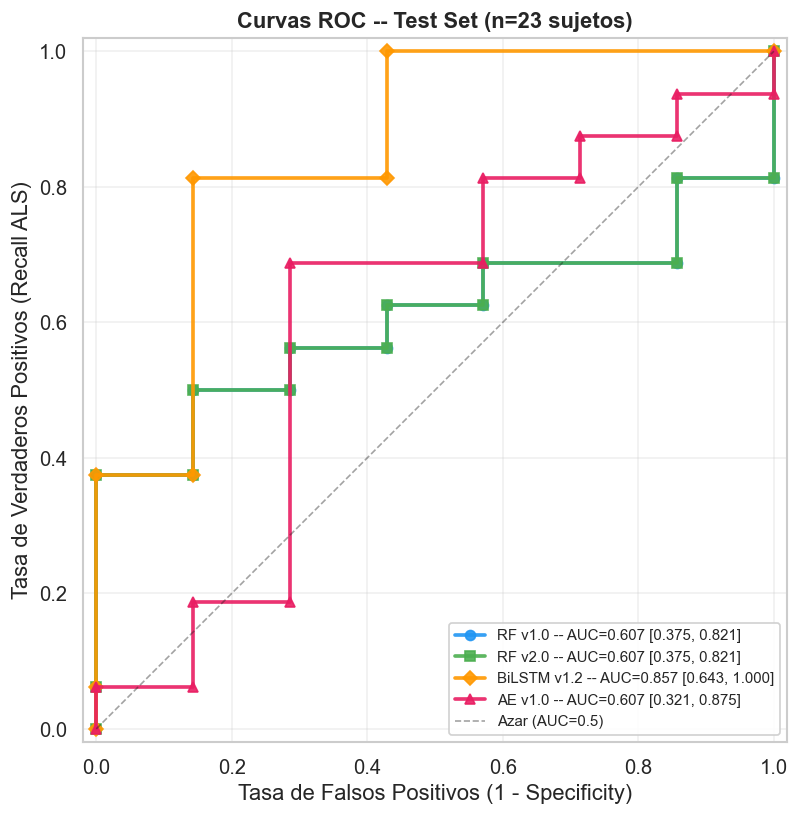

In [ ]:
# CURVAS ROC SUPERPUESTAS 
fig, ax = plt.subplots(figsize=(8, 7))

for display_name, df in predictions.items():
    # Buscar info en MODEL_REGISTRY por clave directa o por short_name
    if display_name in MODEL_REGISTRY:
        info = MODEL_REGISTRY[display_name]
    else:
        # fallback: localizar por short_name
        info = None
        for _, v in MODEL_REGISTRY.items():
            if v.get("short_name") == display_name:
                info = v
                break
        if info is None:
            print(f"[WARN] {display_name}: no está en MODEL_REGISTRY, se omite")
            continue

    fpr, tpr, _ = roc_curve(df["y_true"].values, df["prob_ALS"].values)
    auc_val = roc_auc_score(df["y_true"].values, df["prob_ALS"].values)

    # bootstrap_results está indexado por el mismo display_name (tm_key)
    ci = bootstrap_results.get(display_name, {}).get("AUC", None)
    if ci is None:
        ci_txt = ""
    else:
        ci_txt = f" [{ci['ci_lo']:.3f}, {ci['ci_hi']:.3f}]"

    ax.plot(
        fpr, tpr,
        color=info["color"],
        linewidth=2.2,
        marker=info["marker"],
        markevery=max(1, len(fpr)//8),
        markersize=6,
        alpha=0.9,
        label=f"{info['short_name']} -- AUC={auc_val:.3f}{ci_txt}",
    )

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Specificity)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Recall ALS)")
ax.set_title("Curvas ROC -- Test Set (n=23 sujetos)", fontweight="bold")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_roc.png", bbox_inches="tight")
plt.show()

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 12. Matrices de confusión</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las matrices de confusión normalizadas por fila revelan el perfil de errores de cada modelo. El <b>BiLSTM v1.2</b> detecta correctamente el 81% de los sujetos ALS (13/16) y el 71% de los HC (5/7), el perfil más equilibrado y de mayor rendimiento del conjunto. El <b>AE v1.0</b> muestra el sesgo más pronunciado: 81% de ALS correctos (idéntico al BiLSTM) pero solo 29% de HC, lo que en la práctica clínica significaría derivar a 5 de cada 7 controles sanos a pruebas diagnósticas innecesarias. Los <b>RF v1.0/v2.0</b> presentan un perfil intermedio (63% ALS, 57% HC) con matrices idénticas, confirmación visual adicional de la redundancia de las variables demográficas.
    </span>
</div>

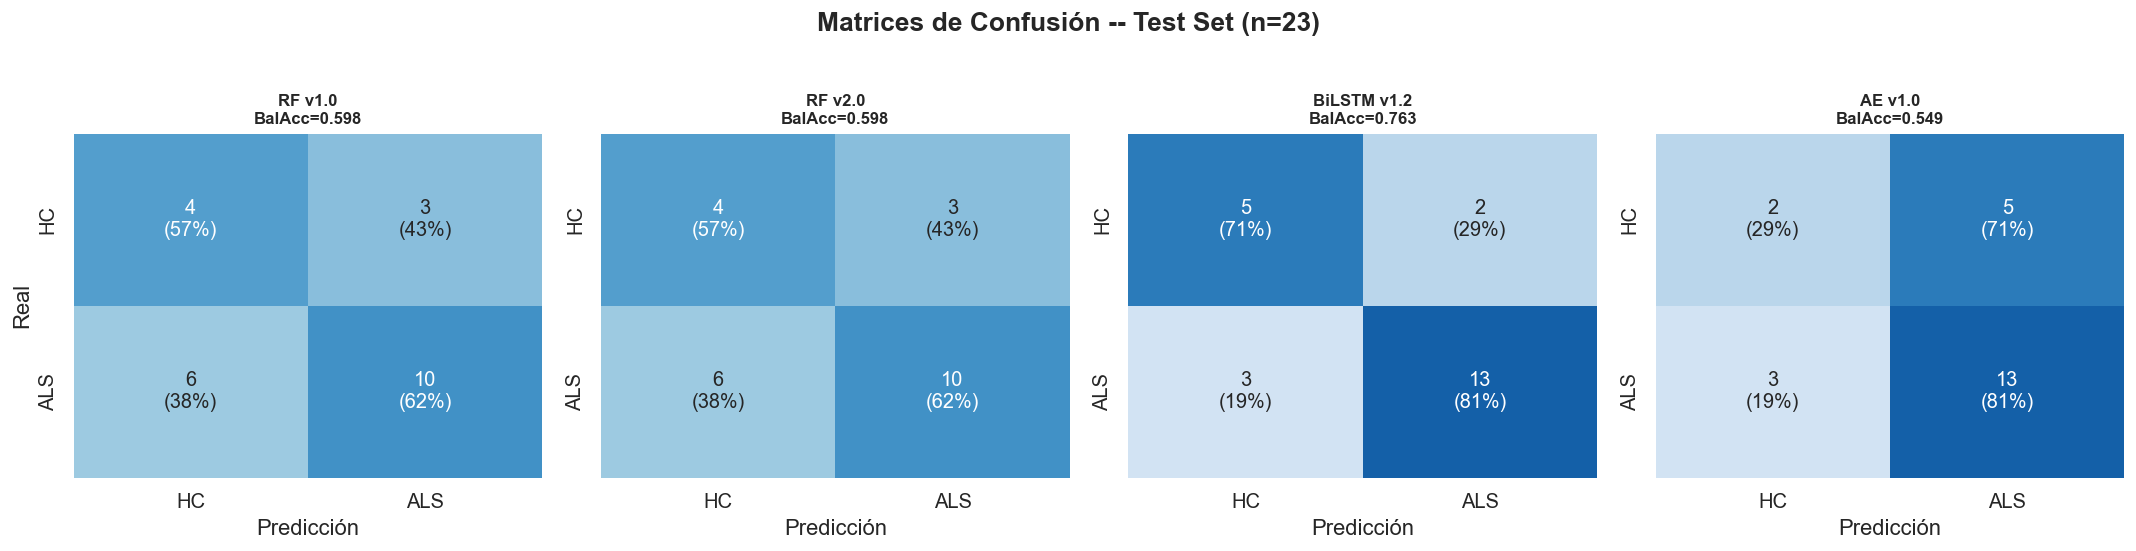

In [ ]:
# MATRICES DE CONFUSIÓN 
def get_model_info(display_name, model_registry):
    # 1) acceso directo
    if display_name in model_registry:
        return model_registry[display_name]
    # 2) fallback por short_name
    for _, v in model_registry.items():
        if v.get("short_name") == display_name:
            return v
    return None

fig, axes = plt.subplots(1, len(predictions), figsize=(18, 4.5))
if len(predictions) == 1:
    axes = [axes]  # por si solo hay 1 modelo

for idx, (display_name, df) in enumerate(predictions.items()):
    ax = axes[idx]

    info = get_model_info(display_name, MODEL_REGISTRY)
    if info is None:
        print(f"[WARN] {display_name}: no está en MODEL_REGISTRY, se omite")
        ax.axis("off")
        continue

    # recomputar y_pred por homogeneidad 
    y_true = df["y_true"].astype(int).values
    prob = df["prob_ALS"].astype(float).values
    y_pred = (prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm, dtype=object)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f"{cm[i, j]}\n({cm_n[i, j]:.0%})"

    sns.heatmap(
        cm_n, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1,
        xticklabels=["HC", "ALS"], yticklabels=["HC", "ALS"],
        cbar=False, ax=ax, annot_kws={"fontsize": 12}
    )

    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real" if idx == 0 else "")
    balacc = test_metrics[display_name]["Balanced Accuracy"]
    ax.set_title(f"{info['short_name']}\nBalAcc={balacc:.3f}", fontweight="bold", fontsize=10)

plt.suptitle("Matrices de Confusión -- Test Set (n=23)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_confusion.png", bbox_inches="tight")
plt.show()

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 13. Barras de métricas con IC 95%</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La visualización de barras con intervalos de confianza permite evaluar simultáneamente la magnitud de cada métrica y su incertidumbre. Las líneas rojas horizontales marcan los umbrales clínicos (Recall ALS ≥ 0.70, BalAcc ≥ 0.60, AUC ≥ 0.70). Solo el BiLSTM supera los tres umbrales en sus estimaciones puntuales, aunque los ICs de todos los modelos cruzan las líneas rojas, lo que refuerza la necesidad de interpretar las diferencias como tendencias más que como conclusiones definitivas.
    </span>
</div>

MODEL_REGISTRY_BY_DISPLAY keys: ['RF v1.0', 'RF v2.0', 'BiLSTM v1.2', 'AE v1.0']


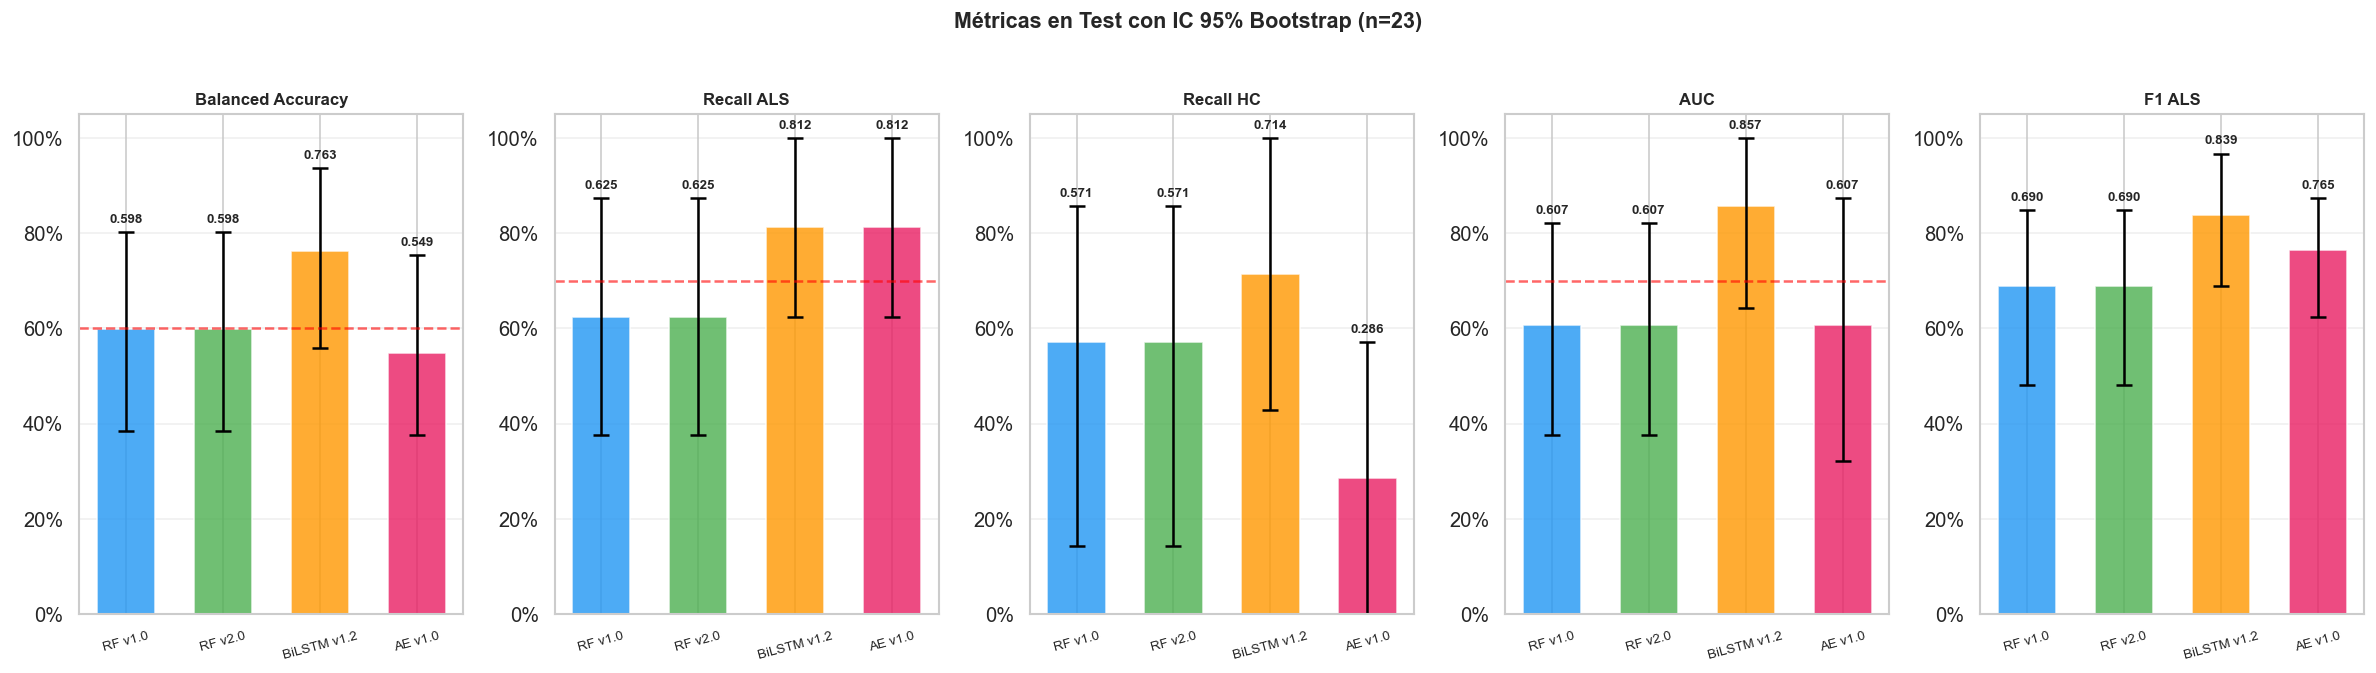

In [ ]:
# MODEL_REGISTRY_BY_DISPLAY: clave = nombre en predictions/test_metrics/bootstrap_results
# (p.ej. "RF v1.0", "BiLSTM v1.2", ...)
MODEL_REGISTRY_BY_DISPLAY = {}

for k, v in MODEL_REGISTRY.items():
    if k in predictions:
        MODEL_REGISTRY_BY_DISPLAY[k] = v
        continue

    display = v.get("tm_key") or v.get("short_name") or k
    MODEL_REGISTRY_BY_DISPLAY[display] = v

print("MODEL_REGISTRY_BY_DISPLAY keys:", list(MODEL_REGISTRY_BY_DISPLAY.keys()))

# BARRAS DE MÉTRICAS CON IC 95%
key_metrics = ["Balanced Accuracy", "Recall ALS", "Recall HC", "AUC", "F1 ALS"]
thresholds = {"Recall ALS": 0.70, "Balanced Accuracy": 0.60, "AUC": 0.70}

names = list(predictions.keys())  # orden consistente con lo que estás usando

fig, axes = plt.subplots(1, len(key_metrics), figsize=(20, 5.5))
if len(key_metrics) == 1:
    axes = [axes]

for mi, mn in enumerate(key_metrics):
    ax = axes[mi]
    pts, clo, chi, cols, labels = [], [], [], [], []

    for display_name in names:
        if display_name not in MODEL_REGISTRY_BY_DISPLAY:
            print(f"[WARN] {display_name}: no está en MODEL_REGISTRY_BY_DISPLAY, se omite")
            continue
        if display_name not in bootstrap_results or mn not in bootstrap_results[display_name]:
            print(f"[WARN] {display_name}: falta bootstrap_results[{display_name}][{mn}], se omite")
            continue

        info = MODEL_REGISTRY_BY_DISPLAY[display_name]
        r = bootstrap_results[display_name][mn]

        pts.append(r["point"])
        clo.append(r["point"] - r["ci_lo"])
        chi.append(r["ci_hi"] - r["point"])
        cols.append(info["color"])
        labels.append(info.get("short_name", display_name))

    x = np.arange(len(pts))
    ax.bar(x, pts, color=cols, alpha=0.8, width=0.6, edgecolor="white")
    ax.errorbar(x, pts, yerr=[clo, chi], fmt="none", ecolor="black", capsize=5, capthick=1.5)

    if mn in thresholds:
        ax.axhline(thresholds[mn], color="red", linestyle="--", alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8, rotation=15)
    ax.set_title(mn, fontweight="bold", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.grid(axis="y", alpha=0.3)

    for i, v in enumerate(pts):
        ax.text(i, v + chi[i] + 0.02, f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Métricas en Test con IC 95% Bootstrap (n=23)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_metrics_ci.png", bbox_inches="tight")
plt.show()

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 14. Distribución de probabilidades por clase</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La distribución de probabilidades P(ALS) separada por clase real es un diagnóstico fundamental de la capacidad discriminativa. Un clasificador ideal mostraría distribuciones completamente separadas. El <b>BiLSTM</b> presenta la mejor separación relativa, con la mayoría de sujetos ALS por encima del umbral 0.5 y la mayoría de HC por debajo. El <b>AE</b> muestra una distribución de HC muy dispersa y desplazada hacia valores altos de P(ALS), lo que explica directamente su elevada tasa de falsos positivos. Los <b>RF</b> muestran distribuciones más compactas pero con un solapamiento considerable entre clases, coherente con su AUC de 0.607.
    </span>
</div>

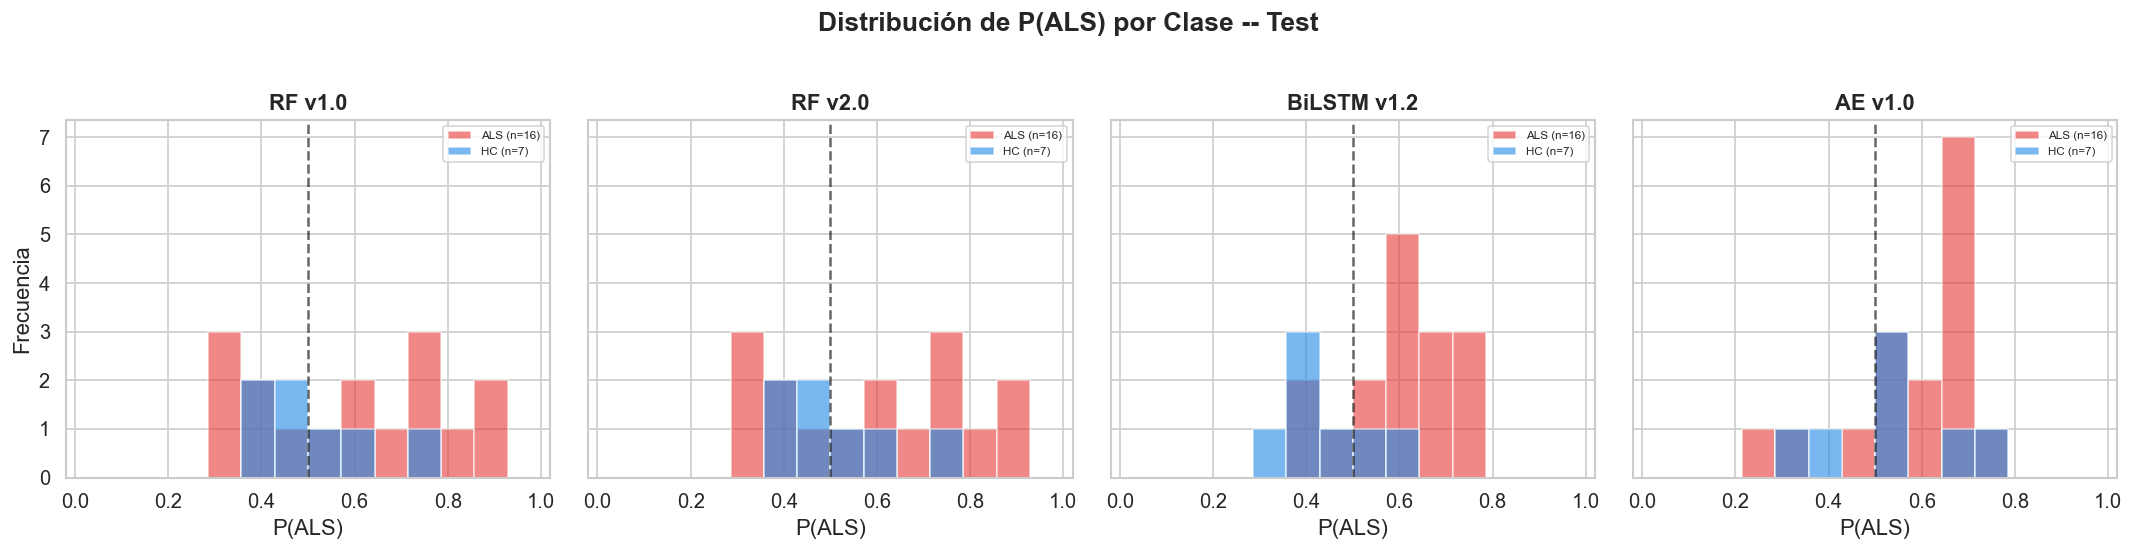

In [ ]:
# DISTRIBUCIÓN DE P(ALS) POR CLASE 
names = list(predictions.keys())
fig, axes = plt.subplots(1, len(names), figsize=(18, 4.5), sharey=True)
if len(names) == 1:
    axes = [axes]

bins = np.linspace(0, 1, 15)

for idx, display_name in enumerate(names):
    df = predictions[display_name]
    ax = axes[idx]

    if display_name not in MODEL_REGISTRY_BY_DISPLAY:
        print(f"[WARN] {display_name}: no está en MODEL_REGISTRY_BY_DISPLAY, se omite")
        ax.axis("off")
        continue

    info = MODEL_REGISTRY_BY_DISPLAY[display_name]

    ax.hist(
        df[df["y_true"] == 1]["prob_ALS"].values,
        bins=bins, alpha=0.6, color="#E53935",
        label=f"ALS (n={(df['y_true']==1).sum()})", edgecolor="white"
    )
    ax.hist(
        df[df["y_true"] == 0]["prob_ALS"].values,
        bins=bins, alpha=0.6, color="#1E88E5",
        label=f"HC (n={(df['y_true']==0).sum()})", edgecolor="white"
    )

    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, alpha=0.6)
    ax.set_xlabel("P(ALS)")
    ax.set_ylabel("Frecuencia" if idx == 0 else "")
    ax.set_title(info.get("short_name", display_name), fontweight="bold")
    ax.legend(fontsize=7)
    ax.set_xlim(-0.02, 1.02)

plt.suptitle("Distribución de P(ALS) por Clase -- Test", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_prob_dist.png", bbox_inches="tight")
plt.show()

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 15. Mapa de errores por sujeto</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El mapa de aciertos por sujeto revela patrones clínicamente relevantes que las métricas agregadas no capturan. El sujeto <b>CT014</b> sigue siendo el único falso positivo universal: los 4 modelos lo clasifican como ALS a pesar de ser un control sano. La universalidad de este error sugiere que sus características acústicas se asemejan genuinamente al perfil de un paciente con disartria.
<br><br>
En el extremo opuesto, <b>7 sujetos</b> son clasificados correctamente por los 4 modelos (PZ004, PZ048, PZ064, PZ065, PZ070, PZ107, PZ112), representando fenotipos acústicos claramente diferenciados. Destaca que todos estos sujetos son ALS (prefijo PZ), lo que indica que existen perfiles de disartria tan marcados que cualquier modelo (independientemente de su arquitectura) los detecta sin ambigüedad. Los sujetos con aciertos parciales representan la frontera de decisión donde la señal de la disartria es ambigua y donde futuras mejoras del modelo tendrían mayor impacto.
    </span>
</div>

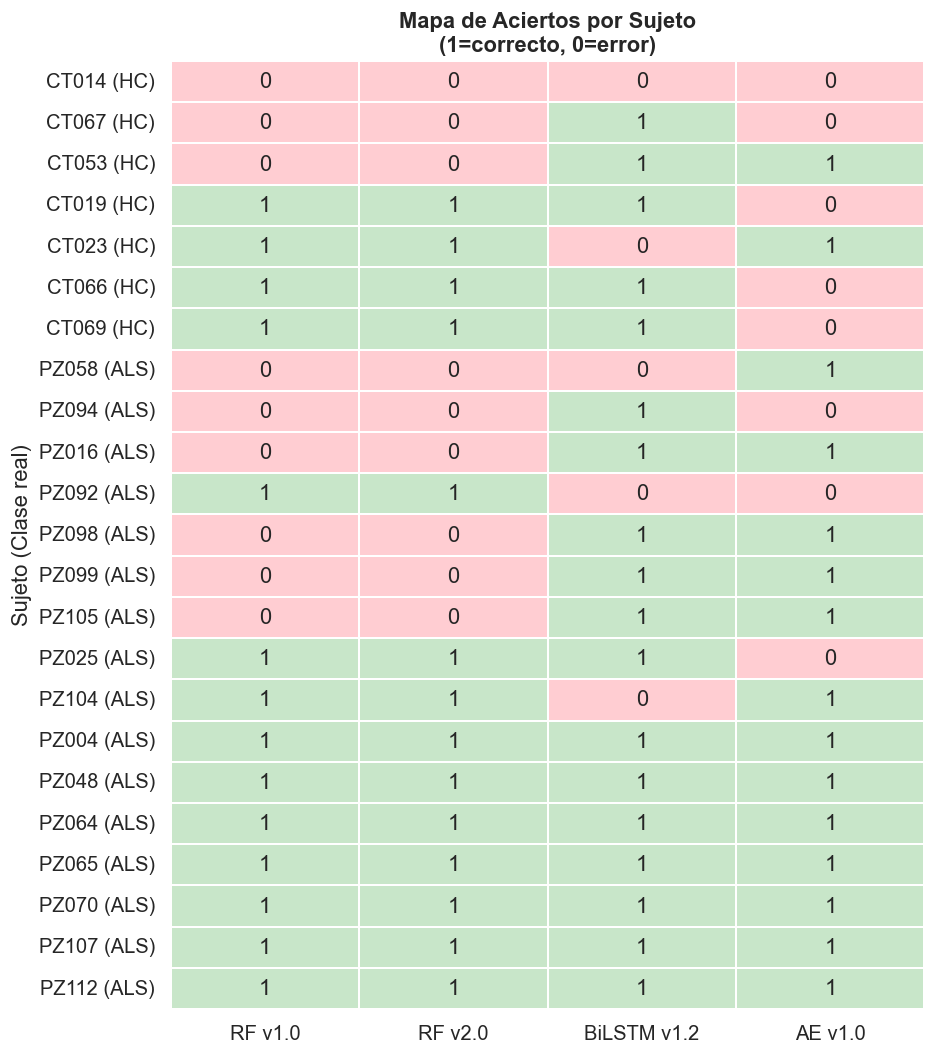

  Sujetos NUNCA correctos: ['CT014']
  Sujetos SIEMPRE correctos: ['PZ004', 'PZ048', 'PZ064', 'PZ065', 'PZ070', 'PZ107', 'PZ112']


In [ ]:
# MAPA DE ERRORES POR SUJETO 
mnl = list(predictions.keys())
all_ids = predictions[mnl[0]]["ID"].values
em = pd.DataFrame(index=all_ids)

col_names = []
for n in mnl:
    if n not in MODEL_REGISTRY_BY_DISPLAY:
        print(f"[WARN] {n}: no está en MODEL_REGISTRY_BY_DISPLAY, se omite")
        continue
    col = MODEL_REGISTRY_BY_DISPLAY[n].get("short_name", n)
    col_names.append(col)
    em[col] = (predictions[n]["y_pred"].values == predictions[n]["y_true"].values).astype(int)

gt = predictions[mnl[0]].set_index("ID")["y_true"]
em["Clase"] = em.index.map(lambda x: "ALS" if int(gt.loc[x]) == 1 else "HC")
em["n_correct"] = em[col_names].sum(axis=1)

em = em.sort_values(["Clase", "n_correct"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(8, 9))
pd_data = em[col_names]

sns.heatmap(
    pd_data,
    annot=True,
    fmt="d",
    cmap=sns.color_palette(["#FFCDD2", "#C8E6C9"]),
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=ax,
    yticklabels=[f"{i} ({em.loc[i, 'Clase']})" for i in em.index],
)

ax.set_title("Mapa de Aciertos por Sujeto\n(1=correcto, 0=error)", fontweight="bold")
ax.set_ylabel("Sujeto (Clase real)")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_error_map.png", bbox_inches="tight")
plt.show()

print(f"  Sujetos NUNCA correctos: {em[em['n_correct'] == 0].index.tolist()}")
print(f"  Sujetos SIEMPRE correctos: {em[em['n_correct'] == len(col_names)].index.tolist()}")

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 16. Radar chart multimétrica</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El radar chart condensa el perfil multimétrica en una sola visualización. El <b>BiLSTM v1.2</b> describe el polígono más grande y equilibrado, sin vértices colapsados hacia el centro. El <b>AE v1.0</b> muestra una forma distorsionada: alto en Recall ALS y F1 ALS, pero colapsado en Recall HC, evidenciando gráficamente el compromiso entre sensibilidad y especificidad. Los polígonos idénticos de ambos RF confirman visualmente su equivalencia funcional.
    </span>
</div>

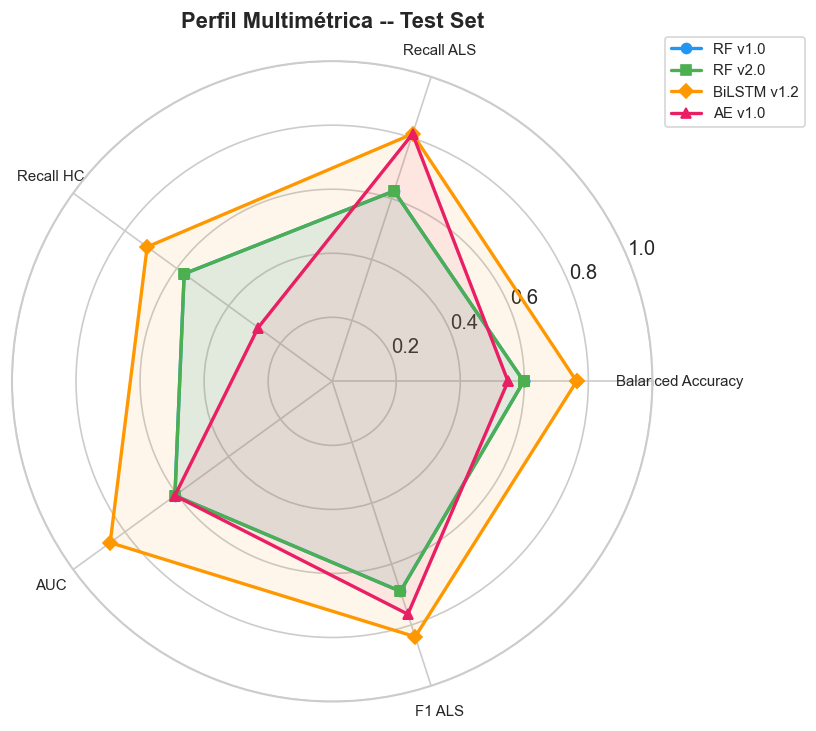

In [34]:
# RADAR CHART (con MODEL_REGISTRY_BY_DISPLAY)
radar_m = ["Balanced Accuracy", "Recall ALS", "Recall HC", "AUC", "F1 ALS"]
angles = np.linspace(0, 2*np.pi, len(radar_m), endpoint=False).tolist()
angles += [angles[0]]  # cerrar polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

names = list(predictions.keys())  # mismo orden que el resto

for display_name in names:
    if display_name not in MODEL_REGISTRY_BY_DISPLAY:
        print(f"[WARN] {display_name}: no está en MODEL_REGISTRY_BY_DISPLAY, se omite")
        continue
    if display_name not in test_metrics:
        print(f"[WARN] {display_name}: no está en test_metrics, se omite")
        continue

    info = MODEL_REGISTRY_BY_DISPLAY[display_name]
    tm = test_metrics[display_name]

    vals = [float(tm[METRIC_KEY_MAP[m]]) for m in radar_m]
    vals += [vals[0]]  # cerrar polígono

    ax.plot(
        angles, vals,
        color=info["color"],
        linewidth=2,
        label=info.get("short_name", display_name),
        marker=info.get("marker", "o"),
        markersize=6
    )
    ax.fill(angles, vals, color=info["color"], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_m, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), fontsize=9)
ax.set_title("Perfil Multimétrica -- Test Set", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_radar.png", bbox_inches="tight")
plt.show()

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 17. Variabilidad CV por fold</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El boxplot revela la estabilidad de cada modelo durante el entrenamiento. Los <b>modelos RF</b> exhiben la mayor dispersión inter-fold (rango ≈ 0.20 puntos en BalAcc), con el fold 1 cayendo por debajo de 0.50, es decir, peor que el azar. Los <b>modelos DL</b> presentan menor variabilidad (rango ≈ 0.08), sugiriendo que la representación aprendida desde espectrogramas es más consistente ante cambios en la partición. El AE es el más estable (std=0.019), aunque esto podría deberse a que su rendimiento está comprimido en un rango modesto. La estabilidad del BiLSTM (std=0.028) combinada con su rendimiento superior lo convierte en el modelo más fiable del conjunto.
    </span>
</div>

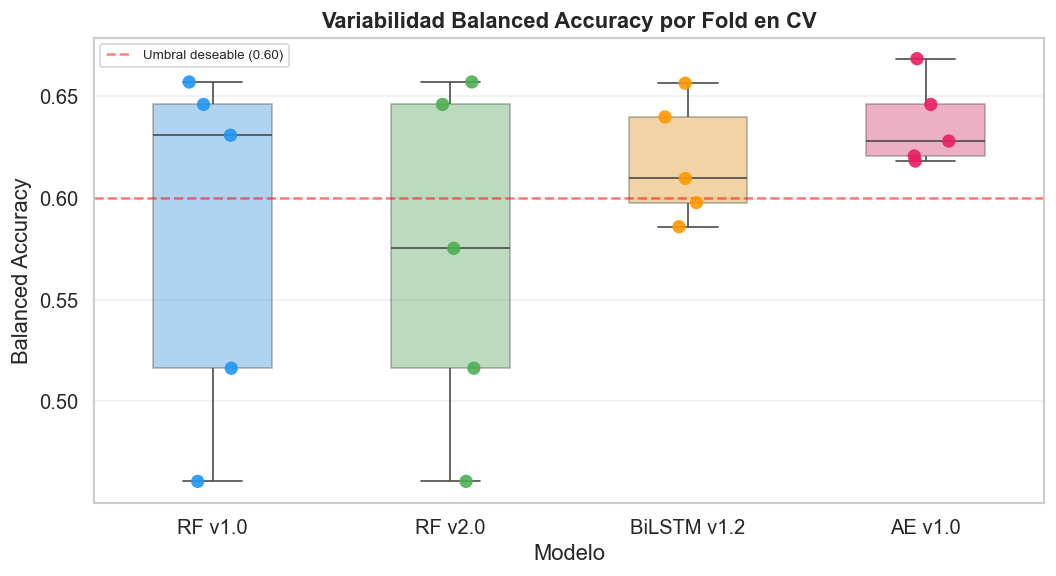

In [35]:
# VARIABILIDAD CV POR FOLD
cvf = []
for n in MODEL_REGISTRY:
    if n not in cv_metrics: continue
    ba = cv_metrics[n]["metrics"].get("balanced_accuracy",{})
    for fi, v in enumerate(ba.get("per_fold",[])): cvf.append({"Modelo":MODEL_REGISTRY[n]["short_name"],"Fold":fi,"BA":v})
if cvf:
    cdf = pd.DataFrame(cvf)
    fig, ax = plt.subplots(figsize=(9,5))
    order = [MODEL_REGISTRY[n]["short_name"] for n in MODEL_REGISTRY if n in cv_metrics]
    pal = {MODEL_REGISTRY[n]["short_name"]: MODEL_REGISTRY[n]["color"] for n in MODEL_REGISTRY}
    sns.boxplot(data=cdf, x="Modelo", y="BA", order=order, palette=pal, width=0.5, boxprops=dict(alpha=0.4), ax=ax)
    sns.stripplot(data=cdf, x="Modelo", y="BA", order=order, palette=pal, size=8, jitter=0.1, alpha=0.9, ax=ax)
    ax.axhline(0.60, color="red", linestyle="--", alpha=0.5, label="Umbral deseable (0.60)")
    ax.set_title("Variabilidad Balanced Accuracy por Fold en CV", fontweight="bold")
    ax.set_ylabel("Balanced Accuracy"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_comparison_cv_folds.png", bbox_inches="tight")
    plt.show()

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. ANÁLISIS DE CONCORDANCIA Y ERRORES CLÍNICOS</span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 18. Concordancia entre modelos</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La matriz de concordancia revela hallazgos de considerable relevancia metodológica. El <b>BiLSTM y los modelos RF coinciden en el 56.5% de sus predicciones</b>, lo que significa que difieren en casi la mitad de los sujetos. Esta divergencia refleja que operan sobre representaciones radicalmente distintas: features acústicas tabulares vs secuencias temporales de espectrogramas mel. Desde la perspectiva del ensemble learning, esta diversidad es deseable porque los errores de un modelo tienden a no coincidir con los del otro.
<br><br>
La concordancia perfecta (1.000) entre RF v1.0 y v2.0 confirma que las variables demográficas no modifican ni una sola predicción individual. La concordancia AE-BiLSTM (0.609) sugiere que, pese a compartir la misma entrada, las arquitecturas producen patrones de error parcialmente distintos, lo que podría explotarse en un ensemble selectivo futuro.
    </span>
</div>

Concordancia:
             RF v1.0  RF v2.0  BiLSTM v1.2  AE v1.0
RF v1.0        1.000    1.000        0.565    0.522
RF v2.0        1.000    1.000        0.565    0.522
BiLSTM v1.2    0.565    0.565        1.000    0.609
AE v1.0        0.522    0.522        0.609    1.000


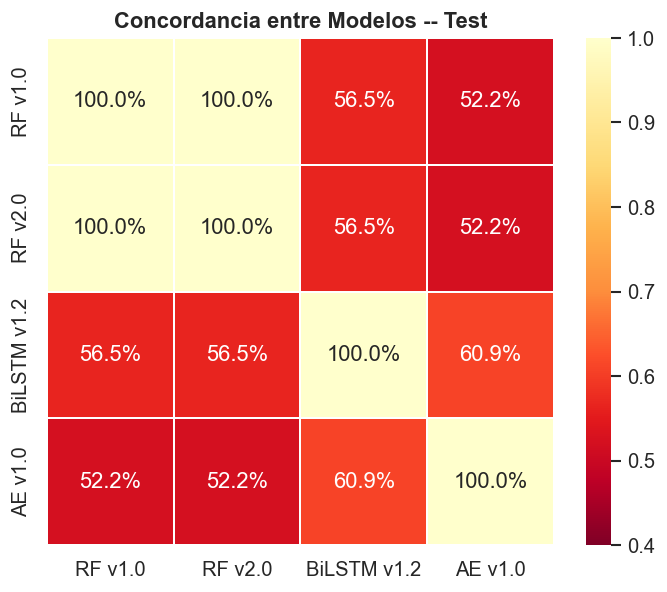

In [ ]:
# CONCORDANCIA ENTRE MODELOS 
mnl = list(predictions.keys())
nm = len(mnl)

cm_c = np.zeros((nm, nm), dtype=float)
for i in range(nm):
    for j in range(nm):
        cm_c[i, j] = np.mean(
            predictions[mnl[i]]["y_pred"].values == predictions[mnl[j]]["y_pred"].values
        )

sn = []
for n in mnl:
    if n in MODEL_REGISTRY_BY_DISPLAY:
        sn.append(MODEL_REGISTRY_BY_DISPLAY[n].get("short_name", n))
    else:
        print(f"[WARN] {n}: no está en MODEL_REGISTRY_BY_DISPLAY, usando nombre literal")
        sn.append(n)

cdf = pd.DataFrame(cm_c, index=sn, columns=sn)

print("Concordancia:")
print(cdf.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cdf,
    annot=True,
    fmt=".1%",
    cmap="YlOrRd_r",
    vmin=0.4,
    vmax=1.0,
    linewidths=1,
    linecolor="white",
    ax=ax,
    square=True,
)

ax.set_title("Concordancia entre Modelos -- Test", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_comparison_concordance.png", bbox_inches="tight")
plt.show()

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 19. Voto mayoritario (ensemble de ensembles)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El voto mayoritario (≥2 de 4 predicen ALS) alcanza un Recall ALS de 0.8750 con un BalAcc de 0.7232. El promedio de probabilidades produce un perfil aún más equilibrado: BalAcc 0.7634 y Recall ALS 0.8125. Ambas estrategias de ensemble igualan o superan al BiLSTM individual en algunas métricas, lo que sugiere que la combinación de modelos puede aportar valor incluso cuando uno de ellos domina claramente. No obstante, el promedio de probabilidades replica exactamente las métricas del BiLSTM (BalAcc 0.7634, Recall ALS 0.8125), lo que indica que las probabilidades del BiLSTM dominan el promedio y que los demás modelos aportan poco a la combinación. Un ensemble selectivo (por ejemplo, solo BiLSTM + AE) podría explotar mejor la complementariedad entre las dos arquitecturas DL sin la dilución de los RF.
    </span>
</div>

In [37]:
# VOTO MAYORITARIO
all_probs = np.column_stack([predictions[n]["prob_ALS"].values for n in mnl])
all_preds = np.column_stack([predictions[n]["y_pred"].values for n in mnl])
yt_test = predictions[mnl[0]]["y_true"].values
mv = (all_preds.sum(axis=1) >= (nm/2)).astype(int)
mp = all_probs.mean(axis=1); mpred = (mp >= 0.5).astype(int)
em_vote = compute_all_metrics(yt_test, mv, mp)
em_avg = compute_all_metrics(yt_test, mpred, mp)
print("Voto mayoritario (>=2/4):")
print(f"  BalAcc={em_vote['Balanced Accuracy']:.4f}, Recall ALS={em_vote['Recall ALS (Sensitivity)']:.4f}, AUC={em_vote['AUC']:.4f}")
print(f"\nPromedio probabilidades:")
print(f"  BalAcc={em_avg['Balanced Accuracy']:.4f}, Recall ALS={em_avg['Recall ALS (Sensitivity)']:.4f}, AUC={em_avg['AUC']:.4f}")

Voto mayoritario (>=2/4):
  BalAcc=0.7232, Recall ALS=0.8750, AUC=0.7232

Promedio probabilidades:
  BalAcc=0.7634, Recall ALS=0.8125, AUC=0.7634


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 20. Análisis clínico de FN y FP</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El análisis de errores revela patrones diferenciados entre familias de modelos. Los <b>modelos RF</b> generan 6 falsos negativos de 16 ALS, con probabilidades P(ALS) bajas (rango 0.29–0.46), indicando convicción del modelo en la predicción errónea. El <b>BiLSTM</b> pierde solo 3 sujetos ALS (PZ058 con P=0.4705, PZ092 con P=0.4013, PZ104 con P=0.4186), todos con probabilidades cercanas al umbral, sugiriendo casos limítrofes donde un ajuste del umbral de decisión podría recuperarlos. El <b>AE</b> también pierde 3 ALS pero genera 5 FP de 7 HC (71%), un ratio inaceptable para cribado clínico. El BiLSTM solo genera 2 FP: CT014 (P=0.6268, el FP universal) y CT023 (P=0.5042, un caso limítrofe con probabilidad apenas sobre 0.5).
<br><br>
<b>CT014</b> es clasificado como ALS por los 4 modelos, con probabilidades entre 0.51 y 0.70, lo que sugiere un perfil acústico genuinamente atípico para un control sano. No existen sujetos ALS que ningún modelo detecte (0 FN comunes), lo que implica que para cada paciente ALS al menos un modelo acierta. Desde la perspectiva del cribado, el BiLSTM ofrece el mejor compromiso global: 3 FN y solo 2 FP.
    </span>
</div>

In [ ]:
# ANÁLISIS CLÍNICO DE ERRORES 
print("=" * 70)
print("ANÁLISIS CLÍNICO DE ERRORES")
print("=" * 70)

mnl = list(predictions.keys())
nm = len(mnl)

# GT e IDs de referencia (mismo para todos tras armonización)
ref_df = predictions[mnl[0]].copy()
yt_ref = ref_df["y_true"].astype(int).values
ids = ref_df["ID"].astype(str).values

# Pre-indexar por ID para consultas rápidas
pred_by_id = {n: predictions[n].set_index("ID") for n in mnl}

for name in mnl:
    df = predictions[name].copy()
    df["y_true"] = df["y_true"].astype(int)
    df["y_pred"] = df["y_pred"].astype(int)

    fn_m = (df["y_true"] == 1) & (df["y_pred"] == 0)
    fp_m = (df["y_true"] == 0) & (df["y_pred"] == 1)

    short = MODEL_REGISTRY_BY_DISPLAY.get(name, {}).get("short_name", name)
    print(f"\n  {short}:")
    print(f"    FN: {int(fn_m.sum())}/{int((df['y_true']==1).sum())}")
    for fid, p in zip(df.loc[fn_m, "ID"], df.loc[fn_m, "prob_ALS"]):
        print(f"      {fid}: P(ALS)={float(p):.4f}")

    print(f"    FP: {int(fp_m.sum())}/{int((df['y_true']==0).sum())}")
    for fid, p in zip(df.loc[fp_m, "ID"], df.loc[fp_m, "prob_ALS"]):
        print(f"      {fid}: P(ALS)={float(p):.4f}")

print("\nFN comunes (ALS no detectado por ningún modelo):")
for aid, y in zip(ids, yt_ref):
    if y != 1:
        continue
    nd = sum(int(pred_by_id[n].loc[aid, "y_pred"]) == 1 for n in mnl)
    if nd == 0:
        print(f"  [!] {aid}: 0/{nm} modelos")

print("\nFP comunes (HC clasificado ALS por todos):")
for hid, y in zip(ids, yt_ref):
    if y != 0:
        continue
    nf = sum(int(pred_by_id[n].loc[hid, "y_pred"]) == 1 for n in mnl)
    if nf == nm:
        print(f"  [!] {hid}: {nm}/{nm} modelos")


ANÁLISIS CLÍNICO DE ERRORES

  RF v1.0:
    FN: 6/16
      PZ016: P(ALS)=0.2912
      PZ058: P(ALS)=0.2857
      PZ094: P(ALS)=0.3050
      PZ098: P(ALS)=0.3714
      PZ099: P(ALS)=0.4586
      PZ105: P(ALS)=0.3948
    FP: 3/7
      CT014: P(ALS)=0.5888
      CT053: P(ALS)=0.7150
      CT067: P(ALS)=0.5120

  RF v2.0:
    FN: 6/16
      PZ016: P(ALS)=0.2912
      PZ058: P(ALS)=0.2857
      PZ094: P(ALS)=0.3050
      PZ098: P(ALS)=0.3714
      PZ099: P(ALS)=0.4586
      PZ105: P(ALS)=0.3948
    FP: 3/7
      CT014: P(ALS)=0.5888
      CT053: P(ALS)=0.7150
      CT067: P(ALS)=0.5120

  BiLSTM v1.2:
    FN: 3/16
      PZ058: P(ALS)=0.4705
      PZ092: P(ALS)=0.4013
      PZ104: P(ALS)=0.4186
    FP: 2/7
      CT014: P(ALS)=0.6268
      CT023: P(ALS)=0.5042

  AE v1.0:
    FN: 3/16
      PZ025: P(ALS)=0.4735
      PZ092: P(ALS)=0.2649
      PZ094: P(ALS)=0.3351
    FP: 5/7
      CT014: P(ALS)=0.7025
      CT019: P(ALS)=0.5443
      CT066: P(ALS)=0.5102
      CT067: P(ALS)=0.5373
      CT06

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 21. Tabla de decisión y ranking final</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La evaluación contra umbrales clínicos establece una clasificación categórica en dos grupos. Los <b>RF v1.0 y v2.0</b> no superan el criterio obligatorio de Recall ALS ≥ 0.70 (ambos obtienen 0.6250) y también fallan en BalAcc y AUC, quedando descartados para cribado diagnóstico. El <b>AE v1.0</b> supera el criterio de Recall ALS (0.8125) pero falla en BalAcc (0.5491) y AUC (0.6071). Solo el <b>BiLSTM v1.2</b> supera los tres umbrales con margen holgado (Recall ALS 0.8125, BalAcc 0.7634, AUC 0.8571).
<br><br>
El ranking por score compuesto sitúa al BiLSTM en primera posición con un score de 0.8016, una ventaja de casi 16 puntos sobre el segundo clasificado (AE v1.0, 0.6426). Esta diferencia es la más amplia de todo el proyecto y proviene de la superioridad del BiLSTM en todas las métricas excepto Recall ALS, donde empata con el AE. La ventaja en BalAcc (+0.214) y AUC (+0.250) es particularmente contundente. Los RF empatan en tercera y cuarta posición (0.6085), reforzando la recomendación de descartar v2.0 por parsimonia.
    </span>
</div>

In [39]:
# EVALUACIÓN CONTRA UMBRALES Y RANKING (robusto con MODEL_REGISTRY_BY_DISPLAY)
print("=" * 80)
print("EVALUACIÓN CONTRA UMBRALES CLÍNICOS")
print("=" * 80)

criteria = [
    ("Recall ALS >= 0.70", "Recall ALS (Sensitivity)", 0.70, True),
    ("BalAcc >= 0.60",     "Balanced Accuracy",        0.60, False),
    ("AUC >= 0.70",        "AUC",                      0.70, False),
]

names = list(predictions.keys())  # orden consistente

drows = []
for display_name in names:
    if display_name not in test_metrics:
        print(f"[WARN] {display_name}: no está en test_metrics, se omite")
        continue
    if display_name not in MODEL_REGISTRY_BY_DISPLAY:
        print(f"[WARN] {display_name}: no está en MODEL_REGISTRY_BY_DISPLAY, se omite")
        continue

    tm = test_metrics[display_name]
    info = MODEL_REGISTRY_BY_DISPLAY[display_name]

    row = {
        "Modelo": info.get("short_name", display_name),
        "Tipo": info.get("type", "N/A"),
        "Interpretable": "Si" if info.get("interpretable", False) else "No",
    }

    pass_mandatory = True
    for cn, mk, th, mand in criteria:
        v = float(tm[mk])
        ok = v >= th
        if mand and not ok:
            pass_mandatory = False
        row[cn] = f"[{'PASS' if ok else 'FAIL'}] {v:.4f}"

    row["Recall HC"] = f"{float(tm['Recall HC (Specificity)']):.4f}"
    row["Pasa obligatorio"] = "SI" if pass_mandatory else "NO"
    drows.append(row)

print(pd.DataFrame(drows).set_index("Modelo").to_string())

print("\n" + "=" * 80)
print("RANKING FINAL")
print("=" * 80)

rdata = []
for display_name in names:
    if display_name not in test_metrics or display_name not in MODEL_REGISTRY_BY_DISPLAY:
        continue

    tm = test_metrics[display_name]
    info = MODEL_REGISTRY_BY_DISPLAY[display_name]

    ra = float(tm["Recall ALS (Sensitivity)"])
    bal = float(tm["Balanced Accuracy"])
    auc = float(tm["AUC"])
    rhc = float(tm["Recall HC (Specificity)"])

    score = 0.40 * ra + 0.25 * bal + 0.25 * auc + 0.10 * rhc

    rdata.append({
        "Modelo": info.get("short_name", display_name),
        "Recall ALS": ra,
        "BalAcc": bal,
        "AUC": auc,
        "Recall HC": rhc,
        "Score": score,
        "Pasa>=0.70": ra >= 0.70,
        "Interpretable": bool(info.get("interpretable", False)),
    })

rdf = pd.DataFrame(rdata)
rdf["sort"] = rdf["Pasa>=0.70"].astype(int) * 10 + rdf["Score"]
rdf = rdf.sort_values("sort", ascending=False).reset_index(drop=True)
rdf.index = rdf.index + 1
rdf.index.name = "Rank"

print(rdf[["Modelo", "Recall ALS", "BalAcc", "AUC", "Recall HC", "Score", "Pasa>=0.70", "Interpretable"]].to_string())

EVALUACIÓN CONTRA UMBRALES CLÍNICOS
            Tipo Interpretable Recall ALS >= 0.70 BalAcc >= 0.60    AUC >= 0.70 Recall HC Pasa obligatorio
Modelo                                                                                                    
RF v1.0      N/A            No      [FAIL] 0.6250  [FAIL] 0.5982  [FAIL] 0.6071    0.5714               NO
RF v2.0      N/A            No      [FAIL] 0.6250  [FAIL] 0.5982  [FAIL] 0.6071    0.5714               NO
BiLSTM v1.2  N/A            No      [PASS] 0.8125  [PASS] 0.7634  [PASS] 0.8571    0.7143               SI
AE v1.0      N/A            No      [PASS] 0.8125  [FAIL] 0.5491  [FAIL] 0.6071    0.2857               SI

RANKING FINAL
           Modelo  Recall ALS    BalAcc       AUC  Recall HC     Score  Pasa>=0.70  Interpretable
Rank                                                                                             
1     BiLSTM v1.2      0.8125  0.763393  0.857143   0.714286  0.801563        True          False
2         AE 

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Conclusiones y recomendación del modelo</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook ha desarrollado una comparativa homogénea y reproducible de cuatro modelos de clasificación binaria ALS vs HC, evaluados sobre el mismo hold-out de test de 23 sujetos del dataset VOC-ALS. Las predicciones se han recalculado íntegramente desde los ficheros crudos con armonización de etiquetas, y la incertidumbre se ha cuantificado mediante bootstrap estratificado (10.000 réplicas) y tests de McNemar exactos.
<br><br>
<ul>
<li><b>Comparación global y recomendación del modelo.</b> De los cuatro modelos evaluados, el <b>BiLSTM v1.2 con ensemble de 5 folds</b> se establece como la mejor opción para clasificación ALS vs HC basada en biomarcadores vocales. Es el único modelo que supera simultáneamente los tres umbrales clínicos predefinidos (Recall ALS 0.8125 ≥ 0.70, Balanced Accuracy 0.7634 ≥ 0.60, AUC 0.8571 ≥ 0.70) y, crucialmente, también alcanza un Recall HC de 0.7143. Su score compuesto de 0.8016 lidera el ranking con 16 puntos de ventaja sobre el segundo clasificado (AE v1.0, 0.6426). La recomendación se basa en cinco pilares convergentes: (1) cumple todos los umbrales clínicos con margen holgado; (2) presenta el perfil de errores más equilibrado del conjunto (3 FN, 2 FP); (3) su AUC de 0.8571 refleja capacidad de ranking genuina, no un sesgo de umbral; (4) sus falsos negativos tienen probabilidades cercanas al umbral (PZ058: 0.4705, PZ092: 0.4013, PZ104: 0.4186), sugiriendo margen de optimización mediante ajuste del punto de corte; y (5) su representación temporal secuencial del habla captura dependencias de la disartria que las features tabulares del RF no alcanzan, como evidencia la diferencia de +17 pp en BalAcc y +25 pp en AUC respecto al baseline RF.</li>
<br>
<li><b>Hallazgos clave.</b> Las variables demográficas (Age, Sex) son completamente irrelevantes: RF v1.0 y v2.0 producen predicciones idénticas en test (0 pares discordantes en McNemar, concordancia 1.000), confirmando el análisis de importancia del Notebook 02 donde Age y Sex quedaron en las posiciones 51 y 52 de 52 en permutation importance. El contraste más revelador es entre BiLSTM y AE: ambos detectan exactamente el mismo número de sujetos ALS (13/16, Recall ALS = 0.8125), pero el BiLSTM lo consigue manteniendo un Recall HC de 0.7143 frente al 0.2857 del AE, una diferencia de 43 puntos porcentuales en especificidad que demuestra que la capacidad discriminativa del BiLSTM es genuina mientras que la del AE proviene de un sesgo hacia la clase mayoritaria. La concordancia RF-BiLSTM (56.5%) indica que ambas familias operan sobre representaciones complementarias, abriendo la puerta a estrategias de ensemble selectivo. El sujeto CT014 es un falso positivo universal (4/4 modelos) que merece verificación clínica.</li>
<br>
<li><b>Limitaciones del estudio.</b> El test set contiene solo 23 sujetos (16 ALS, 7 HC), lo que implica que 1 sujeto mal clasificado representa ~4 pp en BalAcc y ~14 pp en Recall HC. Los intervalos de confianza bootstrap son amplios para todos los modelos, aunque el límite inferior del AUC del BiLSTM (0.6429) supera las estimaciones puntuales de los RF y el AE (0.6071), lo que constituye un indicio de superioridad consistente ante la variabilidad muestral. Ninguna diferencia entre pares alcanza significación estadística por McNemar (p mínimo = 0.3438 para RF vs BiLSTM con 10 discordantes). Las métricas de CV no son directamente comparables entre familias (sample-level en DL vs subject-level en RF). Los datos son transversales (una sesión por sujeto) y las grabaciones fueron realizadas en condiciones acústicas controladas, por lo que el rendimiento podría degradarse en entornos clínicos reales con ruido ambiental y equipos de grabación distintos.</li>
<br>
<li><b>Posibles mejoras futuras.</b> (1) Validación con CV completa y métricas homogéneas subject-level para todos los modelos, reduciendo la incertidumbre asociada al test set de solo 23 sujetos. (2) Ensemble selectivo BiLSTM + AE, explotando la concordancia moderada entre ambos (0.609) sin la dilución que introducen los RF. (3) Optimización del umbral de decisión del BiLSTM mediante análisis de Youden, potencialmente recuperando los FN cercanos al umbral (PZ058: 0.4705, PZ104: 0.4186). (4) Investigación clínica del sujeto CT014 (FP universal) para determinar si presenta rasgos vocales subclínicos de disartria, una patología vocal alternativa, o un artefacto en la grabación. (5) Evaluación de la calibración de probabilidades del BiLSTM para interpretar las salidas como scores de riesgo clínico individualizados. (6) Análisis de rendimiento desglosado por tarea vocal para identificar cuáles son más discriminativas y optimizar el protocolo de cribado.</li>
</ul>
    </span>
</div>

In [40]:
# CONCLUSIONES Y RECOMENDACIÓN FINAL 
print("=" * 80)
print("CONCLUSIONES Y RECOMENDACIÓN FINAL")
print("=" * 80)

best = rdf.iloc[0]
rp = lambda v, t: f"PASS >= {t}" if v >= t else f"FAIL < {t}"

print("\n" + "+" + "="*72 + "+")
print("|{:^72s}|".format("RECOMENDACIÓN DEL MODELO"))
print("+" + "="*72 + "+")
print(f"  Modelo recomendado:  {best['Modelo']}")
print(f"  Score compuesto:     {best['Score']:.4f}")
print(f"  Recall ALS:          {best['Recall ALS']:.4f}  {rp(best['Recall ALS'], 0.70)}")
print(f"  Balanced Accuracy:   {best['BalAcc']:.4f}  {rp(best['BalAcc'], 0.60)}")
print(f"  AUC:                 {best['AUC']:.4f}  {rp(best['AUC'], 0.70)}")
print(f"  Recall HC:           {best['Recall HC']:.4f}")
print(f"  Interpretable:       {'Si' if best['Interpretable'] else 'No'}")
print("+" + "="*72 + "+")

print("\n" + "-"*70)
print("ANÁLISIS DETALLADO:")
print("-"*70)

np_ = int(rdf["Pasa>=0.70"].sum())
print(f"\n1. Criterio obligatorio (Recall ALS >= 0.70): {np_}/{len(rdf)} cumplen.")
for _, r in rdf.iterrows():
    print(f"   - {r['Modelo']}: {r['Recall ALS']:.4f} -> {'CUMPLE' if r['Pasa>=0.70'] else 'NO cumple'}")

print("\n2. RF v1.0 vs RF v2.0: demográficas NO mejoran. Descartar v2.0 por parsimonia.")

# Helper: localizar la clave en test_metrics por short_name
def tm_by_short(short_name: str):
    for display_name, info in MODEL_REGISTRY_BY_DISPLAY.items():
        if info.get("short_name") == short_name and display_name in test_metrics:
            return test_metrics[display_name]
    raise KeyError(f"No encuentro '{short_name}' dentro de test_metrics (claves: {list(test_metrics.keys())})")

bm = tm_by_short("BiLSTM v1.2")
am = tm_by_short("AE v1.0")

print(
    f"\n3. BiLSTM vs AE: BiLSTM supera en BalAcc ({bm['Balanced Accuracy']:.4f} vs {am['Balanced Accuracy']:.4f}) "
    f"y AUC ({bm['AUC']:.4f} vs {am['AUC']:.4f})."
)
print(
    f"   AE tiene alto Recall ALS ({am['Recall ALS (Sensitivity)']:.4f}) "
    f"a costa de Recall HC bajo ({am['Recall HC (Specificity)']:.4f})."
)

print("\n4. ML vs DL: BiLSTM ensemble ofrece mejor balance rendimiento/robustez.")
print("\n5. Limitaciones: n=23 test, ICs amplios, McNemar puede no ser significativo.")

CONCLUSIONES Y RECOMENDACIÓN FINAL

+========================================================================+
|                        RECOMENDACIÓN DEL MODELO                        |
+========================================================================+
  Modelo recomendado:  BiLSTM v1.2
  Score compuesto:     0.8016
  Recall ALS:          0.8125  PASS >= 0.7
  Balanced Accuracy:   0.7634  PASS >= 0.6
  AUC:                 0.8571  PASS >= 0.7
  Recall HC:           0.7143
  Interpretable:       No
+========================================================================+

----------------------------------------------------------------------
ANÁLISIS DETALLADO:
----------------------------------------------------------------------

1. Criterio obligatorio (Recall ALS >= 0.70): 2/4 cumplen.
   - BiLSTM v1.2: 0.8125 -> CUMPLE
   - AE v1.0: 0.8125 -> CUMPLE
   - RF v2.0: 0.6250 -> NO cumple
   - RF v1.0: 0.6250 -> NO cumple

2. RF v1.0 vs RF v2.0: demográficas NO mejoran. Descarta

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 23. Exportación de resultados consolidados</span>
</div>

In [41]:
# EXPORTACIÓN DE RESULTADOS 
# 1) Export final metrics + score + ranking
final_exp = metrics_df.copy()

# metrics_df index suele ser display_name ("RF v1.0", etc.)
# Añadir short_name para unir con rdf["Modelo"]
final_exp["short_name"] = [
    MODEL_REGISTRY_BY_DISPLAY.get(d, {}).get("short_name", d) for d in final_exp.index
]

score_map = dict(zip(rdf["Modelo"], rdf["Score"]))
rank_map = dict(zip(rdf["Modelo"], rdf.index))  # rdf index = Rank (1..)

final_exp["Score"] = final_exp["short_name"].map(score_map)
final_exp["Ranking"] = final_exp["short_name"].map(rank_map)

# (opcional) dejar el CSV bonito
final_exp_out = final_exp.drop(columns=["short_name"])

ep = RESULTS_DIR / "06_comparison_final_metrics.csv"
final_exp_out.round(4).to_csv(ep)
print(f"Exportado: {ep}")

# 2) Export bootstrap CI
ci_rows = []
for display_name, metrics in bootstrap_results.items():
    short = MODEL_REGISTRY_BY_DISPLAY.get(display_name, {}).get("short_name", display_name)
    for mn, r in metrics.items():
        ci_rows.append({
            "Modelo": short,
            "Model_key": display_name,   # por trazabilidad
            "Metrica": mn,
            "Punto": r["point"],
            "CI_lo": r["ci_lo"],
            "CI_hi": r["ci_hi"],
            "boot_mean": r.get("boot_mean", None),
        })

ci_path = RESULTS_DIR / "06_comparison_bootstrap_ci.csv"
pd.DataFrame(ci_rows).round(6).to_csv(ci_path, index=False)
print(f"Exportado: {ci_path}")

# 3) Export McNemar
mr = [{"Par": p, **r} for p, r in mcnemar_results.items()]
mcn_path = RESULTS_DIR / "06_comparison_mcnemar.csv"
pd.DataFrame(mr).to_csv(mcn_path, index=False)
print(f"Exportado: {mcn_path}")

print("\n" + "=" * 70)
print("NOTEBOOK COMPLETADO")
print("=" * 70)

Exportado: C:\Users\Laura\OneDrive\TFG\results\06_comparison_final_metrics.csv
Exportado: C:\Users\Laura\OneDrive\TFG\results\06_comparison_bootstrap_ci.csv
Exportado: C:\Users\Laura\OneDrive\TFG\results\06_comparison_mcnemar.csv

NOTEBOOK COMPLETADO


<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #011b07; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO </b>
<br><br>
Todos los resultados han sido exportados a la carpeta <b>results/</b>.
<br><br>
Artefactos generados:
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>results/06_comparison_final_metrics.csv</code> — Tabla de métricas con ranking
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>results/06_comparison_bootstrap_ci.csv</code> — Intervalos de confianza 95%
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>results/06_comparison_mcnemar.csv</code> — McNemar por pares
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>results/fig_comparison_*.png</code> — 7 figuras comparativas
    </span>
</div>